# Notebook 9: Final Report Results Export and Visualisation

This notebook collects the final results produced by the experiment notebooks and exports report-ready tables, figures and supporting appendix material.

It does not train or evaluate new models. Instead, it reads the saved final outputs from the APS, YCB-28, ModelNet40 and RProp experiments.

The notebook covers:

1. Final AdamW XYZ-only YCB-28 results
2. APS robustness results
3. XYZ + normals versus XYZ-only comparison
4. ModelNet40 primitive-like subset results
5. RProp optimiser comparison
6. Final statistical-test outputs
7. Report and appendix visualisations
8. Export of report-ready tables and figures


In [2]:
# ============================================================
# CELL 2 — Mount Drive, imports, project paths and output folders
# ============================================================

from pathlib import Path
import os
import json
import math
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import mannwhitneyu, kruskal
    SCIPY_AVAILABLE = True
except Exception as e:
    SCIPY_AVAILABLE = False
    print("SciPy not available. Statistical tests will be skipped unless scipy is installed.")

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

# Mount Google Drive
try:
    from google.colab import drive
    if not Path("/content/gdrive/MyDrive").exists():
        drive.mount("/content/gdrive")
except Exception as e:
    print("Drive mount note:", e)

# Detect project folder
PROJECT_CANDIDATES = [
    Path("/content/gdrive/MyDrive/PointNet_APS_Project_V2"),
    Path("/content/drive/MyDrive/PointNet_APS_Project_V2")
]

PROJECT_DIR = None
for p in PROJECT_CANDIDATES:
    if p.exists():
        PROJECT_DIR = p
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not find PointNet_APS_Project_V2 in /content/gdrive or /content/drive."
    )

EXPORT_DIR = PROJECT_DIR / "REPORT_EXPORT_PACKAGE"
TABLE_DIR = EXPORT_DIR / "tables"
FIG_DIR = EXPORT_DIR / "figures"
APPENDIX_DIR = EXPORT_DIR / "appendix"
POINTCLOUD_DIR = FIG_DIR / "pointcloud_visualisations"

for d in [EXPORT_DIR, TABLE_DIR, FIG_DIR, APPENDIX_DIR, POINTCLOUD_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_ORDER = ["box", "cylinder", "sphere"]
LABEL_TO_CLASS = {
    0: "box", 1: "cylinder", 2: "sphere",
    "0": "box", "1": "cylinder", "2": "sphere"
}

print("Project directory:", PROJECT_DIR)
print("Export directory :", EXPORT_DIR)

Mounted at /content/gdrive
Project directory: /content/gdrive/MyDrive/PointNet_APS_Project_V2
Export directory : /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE


In [3]:
# ============================================================
# CELL 3 — Helper functions
# ============================================================

def safe_read_csv(path):
    path = Path(path)
    if not path.exists():
        print("Missing file:", path)
        return None
    try:
        df = pd.read_csv(path)
        print("Loaded:", path)
        print("Shape:", df.shape)
        return df
    except Exception as e:
        print("Could not read:", path)
        print(e)
        return None


def save_table(df, filename, index=False):
    path = TABLE_DIR / filename
    df.to_csv(path, index=index)
    print("Saved table:", path)
    return path


def save_appendix_table(df, filename, index=False):
    path = APPENDIX_DIR / filename
    df.to_csv(path, index=index)
    print("Saved appendix table:", path)
    return path


def save_figure(fig, filename, subfolder=None):
    out_dir = FIG_DIR if subfolder is None else FIG_DIR / subfolder
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)
    return path


def save_appendix_figure(fig, filename):
    path = APPENDIX_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved appendix figure:", path)
    return path


def normalise_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower().replace("-", "_").replace(" ", "_")


def find_column(df, candidates, required=False, label="column"):
    if df is None:
        return None

    cols = list(df.columns)
    lower_map = {c.lower(): c for c in cols}

    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]

    for c in cols:
        c_low = c.lower()
        for cand in candidates:
            if cand.lower() in c_low:
                return c

    if required:
        raise KeyError(
            f"Could not find {label}. Candidates={candidates}. Available columns={cols}"
        )
    return None


def to_class_name(value):
    if pd.isna(value):
        return ""

    if value in LABEL_TO_CLASS:
        return LABEL_TO_CLASS[value]

    s = normalise_text(value)

    if s in LABEL_TO_CLASS:
        return LABEL_TO_CLASS[s]

    if "box" in s:
        return "box"
    if "cylinder" in s or "can" in s:
        return "cylinder"
    if "sphere" in s or "ball" in s:
        return "sphere"

    return s


def standardise_accuracy_column(df):
    if df is None:
        return None

    df = df.copy()

    acc_col = find_column(
        df,
        [
            "test_accuracy_percent",
            "accuracy_percent",
            "mean_accuracy_percent",
            "accuracy",
            "test_accuracy",
            "acc",
            "val_accuracy_percent"
        ],
        required=False,
        label="accuracy column"
    )

    if acc_col is None:
        return df

    values = pd.to_numeric(df[acc_col], errors="coerce")

    # Convert fraction to percent if needed
    if values.dropna().max() <= 1.5:
        values = values * 100.0

    df["accuracy_percent_std"] = values
    return df


def get_condition_col(df):
    return find_column(
        df,
        ["train_condition", "training_condition", "condition", "experiment", "model_condition"],
        required=False,
        label="condition column"
    )


def get_run_col(df):
    return find_column(
        df,
        ["run_id", "run", "seed", "checkpoint_run"],
        required=False,
        label="run column"
    )


def get_object_col(df):
    return find_column(
        df,
        ["object_name", "object", "ycb_object", "category", "category_name", "modelnet_category", "name"],
        required=False,
        label="object/category column"
    )


def add_true_pred_class_columns(df):
    if df is None:
        return None

    df = df.copy()

    true_col = find_column(
        df,
        ["true_class", "true_label", "label", "target", "y_true", "ground_truth"],
        required=False,
        label="true class"
    )

    pred_col = find_column(
        df,
        ["pred_class", "pred_label", "prediction", "predicted_class", "y_pred"],
        required=False,
        label="predicted class"
    )

    if true_col is not None:
        df["true_class_std"] = df[true_col].apply(to_class_name)

    if pred_col is not None:
        df["pred_class_std"] = df[pred_col].apply(to_class_name)

    if "true_class_std" in df.columns and "pred_class_std" in df.columns:
        df["correct_std"] = (df["true_class_std"] == df["pred_class_std"]).astype(int)

    return df


def compute_run_accuracy_from_predictions(df):
    if df is None:
        return None

    df = add_true_pred_class_columns(df)

    if "correct_std" not in df.columns:
        print("Prediction dataframe does not contain true/pred columns.")
        return None

    cond_col = get_condition_col(df)
    run_col = get_run_col(df)

    group_cols = []
    if cond_col is not None:
        group_cols.append(cond_col)
    if run_col is not None:
        group_cols.append(run_col)

    if not group_cols:
        print("No condition/run columns found. Computing one overall accuracy.")
        out = pd.DataFrame([{
            "condition_report": "all",
            "run_report": 1,
            "accuracy_percent": df["correct_std"].mean() * 100,
            "n_samples": len(df)
        }])
        return out

    out = (
        df.groupby(group_cols)
        .agg(
            accuracy_percent=("correct_std", lambda x: x.mean() * 100),
            n_samples=("correct_std", "size")
        )
        .reset_index()
    )

    if cond_col is not None:
        out["condition_report"] = out[cond_col].astype(str)
    else:
        out["condition_report"] = "all"

    if run_col is not None:
        out["run_report"] = out[run_col]
    else:
        out["run_report"] = 1

    return out


def compute_class_accuracy(df):
    if df is None:
        return None

    df = add_true_pred_class_columns(df)

    if "correct_std" not in df.columns:
        return None

    cond_col = get_condition_col(df)
    run_col = get_run_col(df)

    group_cols = []
    if cond_col is not None:
        group_cols.append(cond_col)
    if run_col is not None:
        group_cols.append(run_col)
    group_cols.append("true_class_std")

    per_run = (
        df.groupby(group_cols)
        .agg(
            class_accuracy_percent=("correct_std", lambda x: x.mean() * 100),
            n_samples=("correct_std", "size")
        )
        .reset_index()
    )

    # Average class accuracy across repeated runs
    avg_group_cols = []
    if cond_col is not None:
        avg_group_cols.append(cond_col)
    avg_group_cols.append("true_class_std")

    summary = (
        per_run.groupby(avg_group_cols)
        .agg(
            mean_class_accuracy_percent=("class_accuracy_percent", "mean"),
            std_class_accuracy_percent=("class_accuracy_percent", "std"),
            min_class_accuracy_percent=("class_accuracy_percent", "min"),
            median_class_accuracy_percent=("class_accuracy_percent", "median"),
            max_class_accuracy_percent=("class_accuracy_percent", "max"),
            mean_n_samples=("n_samples", "mean")
        )
        .reset_index()
    )

    return per_run, summary


def compute_object_accuracy(df):
    if df is None:
        return None

    df = add_true_pred_class_columns(df)

    if "correct_std" not in df.columns:
        return None

    cond_col = get_condition_col(df)
    run_col = get_run_col(df)
    object_col = get_object_col(df)

    if object_col is None:
        print("No object/category column found.")
        return None

    group_cols = []
    if cond_col is not None:
        group_cols.append(cond_col)
    if run_col is not None:
        group_cols.append(run_col)

    group_cols += [object_col, "true_class_std"]

    per_run = (
        df.groupby(group_cols)
        .agg(
            object_accuracy_percent=("correct_std", lambda x: x.mean() * 100),
            n_samples=("correct_std", "size")
        )
        .reset_index()
    )

    avg_group_cols = []
    if cond_col is not None:
        avg_group_cols.append(cond_col)

    avg_group_cols += [object_col, "true_class_std"]

    summary = (
        per_run.groupby(avg_group_cols)
        .agg(
            mean_object_accuracy_percent=("object_accuracy_percent", "mean"),
            std_object_accuracy_percent=("object_accuracy_percent", "std"),
            min_object_accuracy_percent=("object_accuracy_percent", "min"),
            median_object_accuracy_percent=("object_accuracy_percent", "median"),
            max_object_accuracy_percent=("object_accuracy_percent", "max"),
            mean_n_samples=("n_samples", "mean")
        )
        .reset_index()
        .sort_values("mean_object_accuracy_percent")
    )

    return per_run, summary


def compute_confusion_matrix(df, class_order=CLASS_ORDER):
    if df is None:
        return None

    df = add_true_pred_class_columns(df)

    if not {"true_class_std", "pred_class_std"}.issubset(df.columns):
        return None

    cm = pd.crosstab(
        pd.Categorical(df["true_class_std"], categories=class_order),
        pd.Categorical(df["pred_class_std"], categories=class_order),
        dropna=False
    )

    cm.index.name = "True class"
    cm.columns.name = "Predicted class"
    return cm


def plot_confusion_matrix(cm, title, filename):
    if cm is None:
        print("No confusion matrix available:", title)
        return None

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm.values)

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns)
    ax.set_yticklabels(cm.index)

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm.values[i, j]:.0f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return save_figure(fig, filename)


def plot_boxplot(df, group_col, value_col, title, ylabel, filename):
    data = df[[group_col, value_col]].dropna().copy()

    if data.empty:
        print("No data for boxplot:", title)
        return None

    groups = list(data[group_col].dropna().unique())
    values = [data.loc[data[group_col] == g, value_col].values for g in groups]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(values, labels=groups, showmeans=True)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

    return save_figure(fig, filename)


def plot_bar(df, x_col, y_col, title, ylabel, filename):
    data = df[[x_col, y_col]].dropna().copy()

    if data.empty:
        print("No data for bar plot:", title)
        return None

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(data[x_col].astype(str), data[y_col].astype(float))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

    return save_figure(fig, filename)


def five_number_summary(values):
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna()

    if len(values) == 0:
        return {
            "n": 0,
            "min": np.nan,
            "q1": np.nan,
            "median": np.nan,
            "q3": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "std": np.nan
        }

    return {
        "n": int(len(values)),
        "min": float(values.min()),
        "q1": float(values.quantile(0.25)),
        "median": float(values.median()),
        "q3": float(values.quantile(0.75)),
        "max": float(values.max()),
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)) if len(values) > 1 else np.nan
    }


def pairwise_mannwhitney(df, group_col, value_col, comparisons=None, label="comparison"):
    if not SCIPY_AVAILABLE:
        print("SciPy not available. Skipping Mann–Whitney tests.")
        return pd.DataFrame()

    data = df[[group_col, value_col]].dropna().copy()

    if comparisons is None:
        groups = list(data[group_col].unique())
        comparisons = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                comparisons.append((groups[i], groups[j]))

    rows = []

    for a, b in comparisons:
        x = pd.to_numeric(data.loc[data[group_col] == a, value_col], errors="coerce").dropna()
        y = pd.to_numeric(data.loc[data[group_col] == b, value_col], errors="coerce").dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        u, p = mannwhitneyu(x, y, alternative="two-sided")

        # Cliff's delta
        greater = 0
        lower = 0
        for xi in x:
            greater += np.sum(xi > y)
            lower += np.sum(xi < y)
        delta = (greater - lower) / (len(x) * len(y))

        rows.append({
            "test_set": label,
            "comparison": f"{a} vs {b}",
            "group_a": a,
            "group_b": b,
            "n_a": len(x),
            "n_b": len(y),
            "mean_a": x.mean(),
            "mean_b": y.mean(),
            "median_a": x.median(),
            "median_b": y.median(),
            "mann_whitney_u": u,
            "p_value": p,
            "cliffs_delta_a_minus_b": delta
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out = out.sort_values("p_value").reset_index(drop=True)
        m = len(out)
        out["holm_rank"] = np.arange(1, m + 1)
        out["holm_adjusted_p"] = [
            min(1.0, out.loc[i, "p_value"] * (m - i)) for i in range(m)
        ]
        out["significant_0.05"] = out["holm_adjusted_p"] < 0.05

    return out


def kruskal_test(df, group_col, value_col, label="comparison"):
    if not SCIPY_AVAILABLE:
        print("SciPy not available. Skipping Kruskal–Wallis test.")
        return pd.DataFrame()

    data = df[[group_col, value_col]].dropna().copy()
    groups = list(data[group_col].unique())

    arrays = [
        pd.to_numeric(data.loc[data[group_col] == g, value_col], errors="coerce").dropna().values
        for g in groups
    ]

    arrays = [a for a in arrays if len(a) > 0]

    if len(arrays) < 2:
        return pd.DataFrame()

    h, p = kruskal(*arrays)

    return pd.DataFrame([{
        "test_set": label,
        "groups": ", ".join(map(str, groups)),
        "kruskal_h": h,
        "p_value": p,
        "significant_0.05": p < 0.05
    }])


def find_csvs(root, keywords=None):
    root = Path(root)

    if not root.exists():
        return []

    files = list(root.rglob("*.csv"))

    if keywords is None:
        return files

    selected = []
    for f in files:
        s = str(f).lower()
        if all(k.lower() in s for k in keywords):
            selected.append(f)

    return selected


print("Helper functions ready.")

Helper functions ready.


In [4]:
# ============================================================
# CELL 4 — Expected final result file paths
# ============================================================

PATHS = {
    # Main AdamW XYZ-only YCB-28 results
    "ycb_summary": (
        PROJECT_DIR
        / "results_final_xyz"
        / "ycb28_results"
        / "pointnetpp_xyz_aps_to_ycb28_summary_runs.csv"
    ),

    "ycb_predictions": (
        PROJECT_DIR
        / "results_final_xyz"
        / "ycb28_results"
        / "pointnetpp_xyz_aps_to_ycb28_all_predictions_runs.csv"
    ),

    # APS test results
    "aps_summary": (
        PROJECT_DIR
        / "results_final_xyz"
        / "aps_test_results"
        / "pointnetpp_xyz_aps_test_summary_runs.csv"
    ),

    "aps_predictions": (
        PROJECT_DIR
        / "results_final_xyz"
        / "aps_test_results"
        / "pointnetpp_xyz_aps_test_all_predictions_runs.csv"
    ),

    # Final AdamW training status
    "notebook5_status": (
        PROJECT_DIR
        / "results_final_xyz"
        / "statistics"
        / "05_xyz_only_adamw_training_ycb28_status.json"
    ),

    # Original XYZ + normals YCB-28 comparison
    "original_normals_ycb": (
        PROJECT_DIR
        / "results_final"
        / "ycb28_results"
        / "pointnetpp_aps_to_ycb28_summary_runs_1_to_9.csv"
    ),

    # YCB-28 point-cloud manifest
    "ycb_manifest": (
        PROJECT_DIR
        / "metadata"
        / "ycb28_pointcloud_manifest_bbox_norm.csv"
    ),

    # ModelNet40 results
    "modelnet_dir": (
        PROJECT_DIR
        / "results_final_xyz"
        / "modelnet40_results"
    ),

    # RProp results
    "rprop_dir": (
        PROJECT_DIR
        / "RPROP_OPTIMIZER_COMPARISON"
    )
}

for key, path in PATHS.items():
    print(f"{key:25s} -> {path} | exists: {Path(path).exists()}")

ycb_summary               -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_summary_runs.csv | exists: True
ycb_predictions           -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_all_predictions_runs.csv | exists: True
aps_summary               -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_summary_runs.csv | exists: True
aps_predictions           -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_all_predictions_runs.csv | exists: True
notebook5_status          -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/statistics/05_xyz_only_adamw_training_ycb28_status.json | exists: True
original_normals_ycb      -> /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final/ycb28_results/pointnetpp_aps_to_ycb28_summary_runs_1_

Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_summary_runs.csv
Shape: (27, 13)
Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/ycb28_results/pointnetpp_xyz_aps_to_ycb28_all_predictions_runs.csv
Shape: (15120, 20)
YCB summary columns:
['train_condition', 'run_id', 'test_set', 'test_accuracy', 'test_accuracy_percent', 'correct_predictions', 'wrong_predictions', 'total_samples', 'box_accuracy_percent', 'cylinder_accuracy_percent', 'sphere_accuracy_percent', 'confusion_matrix_path', 'prediction_path', 'accuracy_percent_std']


,train_condition,run_id,test_set,test_accuracy,test_accuracy_percent,correct_predictions,wrong_predictions,total_samples,box_accuracy_percent,cylinder_accuracy_percent,sphere_accuracy_percent,confusion_matrix_path,prediction_path,accuracy_percent_std
0,clean_trained_xyz,1,ycb28,0.794643,79.464286,445,115,560,88.888889,53.750,90.454545,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,79.464286
1,clean_trained_xyz,2,ycb28,0.837500,83.750000,469,91,560,83.333333,74.375,90.909091,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,83.750000
2,clean_trained_xyz,3,ycb28,0.819643,81.964286,459,101,560,85.000000,66.250,90.909091,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,81.964286
3,clean_trained_xyz,4,ycb28,0.816071,81.607143,457,103,560,92.222222,56.875,90.909091,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,81.607143
4,clean_trained_xyz,5,ycb28,0.841071,84.107143,471,89,560,88.888889,69.375,90.909091,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,84.107143


YCB prediction columns:
['path', 'object_name', 'class_name', 'label', 'sample_id', 'variant', 'role', 'source_mesh', 'source_type', 'n_points', 'original_drive_path', 'true_label', 'pred_label', 'true_class', 'pred_class', 'confidence', 'correct', 'train_condition', 'run_id', 'test_set', 'true_class_std', 'pred_class_std', 'correct_std']


,path,object_name,class_name,label,sample_id,variant,role,source_mesh,source_type,n_points,...,true_class,pred_class,confidence,correct,train_condition,run_id,test_set,true_class_std,pred_class_std,correct_std
0,/content/pointnetpp_xyz_cache/ycb28_test/box/0...,003_cracker_box,box,0,0,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000,...,box,box,0.916041,True,clean_trained_xyz,1,ycb28,box,box,1
1,/content/pointnetpp_xyz_cache/ycb28_test/box/0...,003_cracker_box,box,0,1,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000,...,box,box,0.856570,True,clean_trained_xyz,1,ycb28,box,box,1
2,/content/pointnetpp_xyz_cache/ycb28_test/box/0...,003_cracker_box,box,0,2,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000,...,box,box,0.959106,True,clean_trained_xyz,1,ycb28,box,box,1
3,/content/pointnetpp_xyz_cache/ycb28_test/box/0...,003_cracker_box,box,0,3,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000,...,box,box,0.919383,True,clean_trained_xyz,1,ycb28,box,box,1
4,/content/pointnetpp_xyz_cache/ycb28_test/box/0...,003_cracker_box,box,0,4,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000,...,box,box,0.960329,True,clean_trained_xyz,1,ycb28,box,box,1


,train_condition,run_id,accuracy_percent,n_samples,condition_report,run_report
0,clean_trained_xyz,1,79.464286,560,clean_trained_xyz,1
1,clean_trained_xyz,2,83.750000,560,clean_trained_xyz,2
2,clean_trained_xyz,3,81.964286,560,clean_trained_xyz,3
3,clean_trained_xyz,4,81.607143,560,clean_trained_xyz,4
4,clean_trained_xyz,5,84.107143,560,clean_trained_xyz,5
5,clean_trained_xyz,6,86.785714,560,clean_trained_xyz,6
6,clean_trained_xyz,7,83.571429,560,clean_trained_xyz,7
7,clean_trained_xyz,8,81.607143,560,clean_trained_xyz,8
8,clean_trained_xyz,9,83.571429,560,clean_trained_xyz,9
9,error_trained_xyz,1,87.500000,560,error_trained_xyz,1


...

Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section1_ycb28_final_adamw_mixed_aggregated_confusion_matrix.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_ycb28_final_adamw_mixed_confusion_matrix.png
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_mixed_adamw_confusion_matrix_run_1.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_mixed_adamw_confusion_matrix_run_2.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_mixed_adamw_confusion_matrix_run_3.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_mixed_adamw_confusion_matrix_run_4.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPO

,train_condition,object_name,true_class_std,mean_object_accuracy_percent,std_object_accuracy_percent,min_object_accuracy_percent,median_object_accuracy_percent,max_object_accuracy_percent,mean_n_samples
25,clean_trained_xyz,063_a_marbles,sphere,0.000000,0.000000,0.0,0.0,0.0,20.0
53,error_trained_xyz,063_a_marbles,sphere,0.000000,0.000000,0.0,0.0,0.0,20.0
81,mixed_trained_xyz,063_a_marbles,sphere,0.000000,0.000000,0.0,0.0,0.0,20.0
46,error_trained_xyz,040_large_marker,cylinder,9.444444,16.287350,0.0,0.0,40.0,20.0
26,clean_trained_xyz,065_a_cups,cylinder,11.666667,15.612495,0.0,5.0,40.0,20.0
18,clean_trained_xyz,040_large_marker,cylinder,15.000000,19.843135,0.0,10.0,60.0,20.0
16,clean_trained_xyz,026_sponge,box,28.333333,17.320508,0.0,30.0,50.0,20.0
44,error_trained_xyz,026_sponge,box,28.888889,26.783598,0.0,25.0,85.0,20.0
74,mixed_trained_xyz,040_large_marker,cylinder,33.333333,25.495098,0.0,35.0,60.0,20.0
15,clean_trained_xyz,025_mug,cylinder,35.555556,23.775571,5.0,35.0,65.0,20.0


Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_object_accuracy_per_run.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_object_accuracy_summary.csv


,train_condition,object_name,true_class_std,mean_object_accuracy_percent,std_object_accuracy_percent,min_object_accuracy_percent,median_object_accuracy_percent,max_object_accuracy_percent,mean_n_samples
81,mixed_trained_xyz,063_a_marbles,sphere,0.000000,0.000000,0.0,0.0,0.0,20.0
74,mixed_trained_xyz,040_large_marker,cylinder,33.333333,25.495098,0.0,35.0,60.0,20.0
72,mixed_trained_xyz,026_sponge,box,36.666667,25.980762,0.0,35.0,75.0,20.0
82,mixed_trained_xyz,065_a_cups,cylinder,86.111111,14.092945,50.0,90.0,95.0,20.0
63,mixed_trained_xyz,009_gelatin_box,box,88.888889,10.240171,65.0,90.0,100.0,20.0
62,mixed_trained_xyz,008_pudding_box,box,90.555556,10.441637,75.0,90.0,100.0,20.0
71,mixed_trained_xyz,025_mug,cylinder,91.666667,7.500000,75.0,90.0,100.0,20.0
60,mixed_trained_xyz,005_tomato_soup_can,cylinder,92.777778,8.333333,75.0,95.0,100.0,20.0
64,mixed_trained_xyz,010_potted_meat_can,box,93.333333,7.905694,75.0,95.0,100.0,20.0
59,mixed_trained_xyz,004_sugar_box,box,96.111111,8.207382,75.0,100.0,100.0,20.0


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section1_ycb28_weakest_objects_final_adamw_mixed.csv


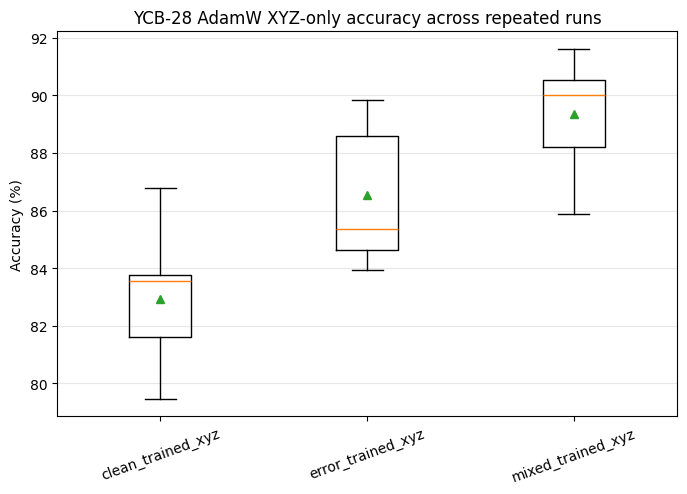

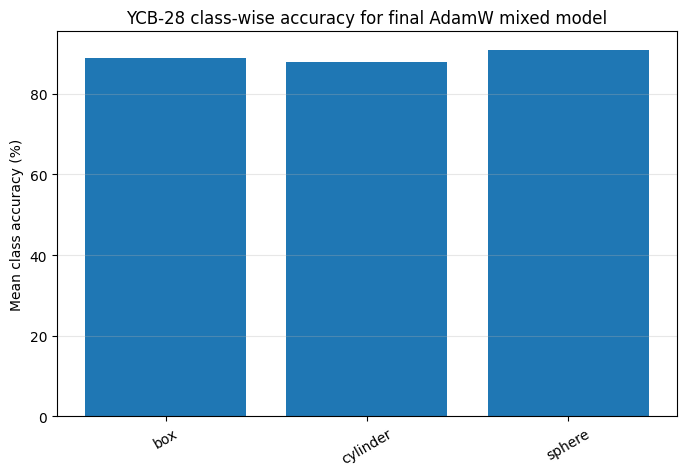

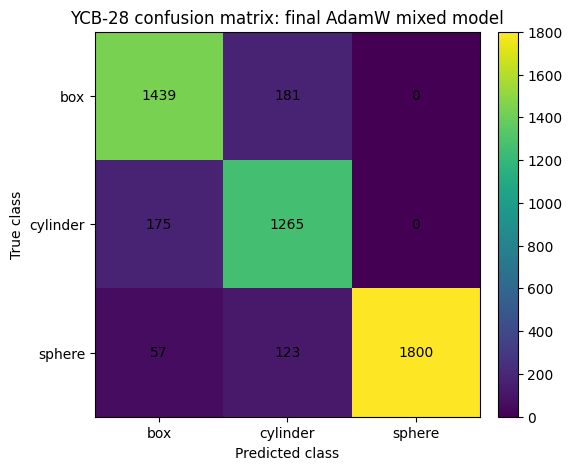

In [5]:
# ============================================================
# CELL 5 — Section 1: Final AdamW XYZ-only YCB-28 results
# ============================================================

ycb_summary = safe_read_csv(PATHS["ycb_summary"])
ycb_predictions = safe_read_csv(PATHS["ycb_predictions"])

if ycb_summary is not None:
    ycb_summary = standardise_accuracy_column(ycb_summary)
    print("YCB summary columns:")
    print(list(ycb_summary.columns))
    display(ycb_summary.head())

if ycb_predictions is not None:
    ycb_predictions = add_true_pred_class_columns(ycb_predictions)
    print("YCB prediction columns:")
    print(list(ycb_predictions.columns))
    display(ycb_predictions.head())

# Run-level accuracy table
if ycb_predictions is not None and "correct_std" in ycb_predictions.columns:
    ycb_run_accuracy = compute_run_accuracy_from_predictions(ycb_predictions)
elif ycb_summary is not None and "accuracy_percent_std" in ycb_summary.columns:
    cond_col = get_condition_col(ycb_summary)
    run_col = get_run_col(ycb_summary)

    ycb_run_accuracy = ycb_summary.copy()
    ycb_run_accuracy["accuracy_percent"] = ycb_run_accuracy["accuracy_percent_std"]

    if cond_col is not None:
        ycb_run_accuracy["condition_report"] = ycb_run_accuracy[cond_col].astype(str)
    else:
        ycb_run_accuracy["condition_report"] = "unknown"

    if run_col is not None:
        ycb_run_accuracy["run_report"] = ycb_run_accuracy[run_col]
    else:
        ycb_run_accuracy["run_report"] = np.arange(1, len(ycb_run_accuracy) + 1)
else:
    ycb_run_accuracy = None

if ycb_run_accuracy is not None:
    display(ycb_run_accuracy)
    save_table(ycb_run_accuracy, "section1_ycb28_adamw_run_level_accuracy.csv")

    # Five-number summary by condition
    ycb_five_rows = []
    for cond, sub in ycb_run_accuracy.groupby("condition_report"):
        stats = five_number_summary(sub["accuracy_percent"])
        stats["condition"] = cond
        ycb_five_rows.append(stats)

    ycb_five_summary = pd.DataFrame(ycb_five_rows)[
        ["condition", "n", "min", "q1", "median", "q3", "max", "mean", "std"]
    ]

    display(ycb_five_summary)
    save_table(ycb_five_summary, "section1_ycb28_adamw_five_number_summary.csv")

    # Box plot
    plot_boxplot(
        ycb_run_accuracy,
        "condition_report",
        "accuracy_percent",
        "YCB-28 AdamW XYZ-only accuracy across repeated runs",
        "Accuracy (%)",
        "figure_ycb28_adamw_clean_error_mixed_boxplot.png"
    )

# Class-wise accuracy
if ycb_predictions is not None:
    class_result = compute_class_accuracy(ycb_predictions)

    if class_result is not None:
        ycb_class_per_run, ycb_class_summary = class_result

        display(ycb_class_summary)
        save_table(ycb_class_per_run, "section1_ycb28_class_accuracy_per_run.csv")
        save_table(ycb_class_summary, "section1_ycb28_class_accuracy_summary.csv")

        # Final mixed class-wise bar chart
        cond_col = get_condition_col(ycb_class_summary)
        if cond_col is not None:
            mixed_class_summary = ycb_class_summary[
                ycb_class_summary[cond_col].astype(str).str.lower().str.contains("mixed")
            ].copy()
        else:
            mixed_class_summary = ycb_class_summary.copy()

        if not mixed_class_summary.empty:
            plot_bar(
                mixed_class_summary,
                "true_class_std",
                "mean_class_accuracy_percent",
                "YCB-28 class-wise accuracy for final AdamW mixed model",
                "Mean class accuracy (%)",
                "figure_ycb28_final_adamw_classwise_accuracy.png"
            )

# Confusion matrix for final mixed model
if ycb_predictions is not None:
    cond_col = get_condition_col(ycb_predictions)
    run_col = get_run_col(ycb_predictions)

    if cond_col is not None:
        ycb_mixed_predictions = ycb_predictions[
            ycb_predictions[cond_col].astype(str).str.lower().str.contains("mixed")
        ].copy()
    else:
        ycb_mixed_predictions = ycb_predictions.copy()

    # Aggregated confusion matrix over all mixed runs
    ycb_mixed_cm = compute_confusion_matrix(ycb_mixed_predictions)

    if ycb_mixed_cm is not None:
        display(ycb_mixed_cm)
        save_table(ycb_mixed_cm.reset_index(), "section1_ycb28_final_adamw_mixed_aggregated_confusion_matrix.csv")
        plot_confusion_matrix(
            ycb_mixed_cm,
            "YCB-28 confusion matrix: final AdamW mixed model",
            "figure_ycb28_final_adamw_mixed_confusion_matrix.png"
        )

    # Individual confusion matrices for appendix
    if run_col is not None and not ycb_mixed_predictions.empty:
        for run_id, sub in ycb_mixed_predictions.groupby(run_col):
            cm = compute_confusion_matrix(sub)
            if cm is not None:
                save_appendix_table(
                    cm.reset_index(),
                    f"appendix_ycb28_mixed_adamw_confusion_matrix_run_{run_id}.csv"
                )

# Object-wise accuracy
if ycb_predictions is not None:
    object_result = compute_object_accuracy(ycb_predictions)

    if object_result is not None:
        ycb_object_per_run, ycb_object_summary = object_result

        display(ycb_object_summary.head(20))
        save_appendix_table(ycb_object_per_run, "appendix_ycb28_object_accuracy_per_run.csv")
        save_appendix_table(ycb_object_summary, "appendix_ycb28_object_accuracy_summary.csv")

        cond_col = get_condition_col(ycb_object_summary)

        if cond_col is not None:
            ycb_object_mixed = ycb_object_summary[
                ycb_object_summary[cond_col].astype(str).str.lower().str.contains("mixed")
            ].copy()
        else:
            ycb_object_mixed = ycb_object_summary.copy()

        if not ycb_object_mixed.empty:
            weakest_ycb_objects = ycb_object_mixed.sort_values("mean_object_accuracy_percent").head(10)
            display(weakest_ycb_objects)
            save_table(weakest_ycb_objects, "section1_ycb28_weakest_objects_final_adamw_mixed.csv")

Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_summary_runs.csv
Shape: (81, 13)
Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/pointnetpp_xyz_aps_test_all_predictions_runs.csv
Shape: (48600, 18)
APS summary columns:
['train_condition', 'run_id', 'test_set', 'test_accuracy', 'test_accuracy_percent', 'correct_predictions', 'wrong_predictions', 'total_samples', 'box_accuracy_percent', 'cylinder_accuracy_percent', 'sphere_accuracy_percent', 'confusion_matrix_path', 'prediction_path', 'accuracy_percent_std']


,train_condition,run_id,test_set,test_accuracy,test_accuracy_percent,correct_predictions,wrong_predictions,total_samples,box_accuracy_percent,cylinder_accuracy_percent,sphere_accuracy_percent,confusion_matrix_path,prediction_path,accuracy_percent_std
0,clean_trained_xyz,1,aps_clean_test,1.000000,100.000000,600,0,600,100.0,100.0,100.0,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,100.000000
1,clean_trained_xyz,1,aps_error_test,0.991667,99.166667,595,5,600,100.0,97.5,100.0,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,99.166667
2,clean_trained_xyz,1,aps_error_double_test,0.568333,56.833333,341,259,600,99.0,42.0,29.5,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,56.833333
3,clean_trained_xyz,2,aps_clean_test,1.000000,100.000000,600,0,600,100.0,100.0,100.0,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,100.000000
4,clean_trained_xyz,2,aps_error_test,1.000000,100.000000,600,0,600,100.0,100.0,100.0,/content/drive/MyDrive/PointNet_APS_Project_V2...,/content/drive/MyDrive/PointNet_APS_Project_V2...,100.000000


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section2_aps_test_summary_raw.csv


,train_condition,test_set,train_short,test_short,plot_group,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,n_runs
0,clean_trained_xyz,aps_clean_test,Clean,APS clean,Clean train\nAPS clean,99.981481,0.055556,99.833333,100.000000,100.000000,9
2,clean_trained_xyz,aps_error_test,Clean,APS error,Clean train\nAPS error,99.703704,0.423099,98.833333,99.833333,100.000000,9
1,clean_trained_xyz,aps_error_double_test,Clean,APS error-double,Clean train\nAPS error-double,68.000000,12.125215,50.000000,69.666667,83.500000,9
3,error_trained_xyz,aps_clean_test,Error,APS clean,Error train\nAPS clean,99.981481,0.055556,99.833333,100.000000,100.000000,9
5,error_trained_xyz,aps_error_test,Error,APS error,Error train\nAPS error,99.907407,0.121081,99.666667,100.000000,100.000000,9
4,error_trained_xyz,aps_error_double_test,Error,APS error-double,Error train\nAPS error-double,98.740741,0.702728,97.000000,98.833333,99.500000,9
6,mixed_trained_xyz,aps_clean_test,Mixed,APS clean,Mixed train\nAPS clean,99.944444,0.166667,99.500000,100.000000,100.000000,9
8,mixed_trained_xyz,aps_error_test,Mixed,APS error,Mixed train\nAPS error,99.962963,0.111111,99.666667,100.000000,100.000000,9
7,mixed_trained_xyz,aps_error_double_test,Mixed,APS error-double,Mixed train\nAPS error-double,98.592593,1.000386,97.000000,98.833333,99.833333,9


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section2_aps_test_result_summary.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_aps_test_accuracy_boxplot.png
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_aps_test_mean_accuracy_bar.png
Notebook 5 training status:
{
  "notebook": "05_xyz_only_adamw_training_ycb28",
  "purpose": "Train XYZ-only PointNet++ models on APS and evaluate them on APS and YCB-28",
  "input_type": "XYZ only",
  "use_normals": false,
  "n_points": 1000,
  "epochs": 50,
  "run_ids": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ],
  "train_conditions": [
    "clean_trained_xyz",
    "error_trained_xyz",
    "mixed_trained_xyz"
  ],
  "checkpoint_count": 27,
  "expected_checkpoint_count": 27,
  "aps_summary_path": "/content/drive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/aps_test_results/poi

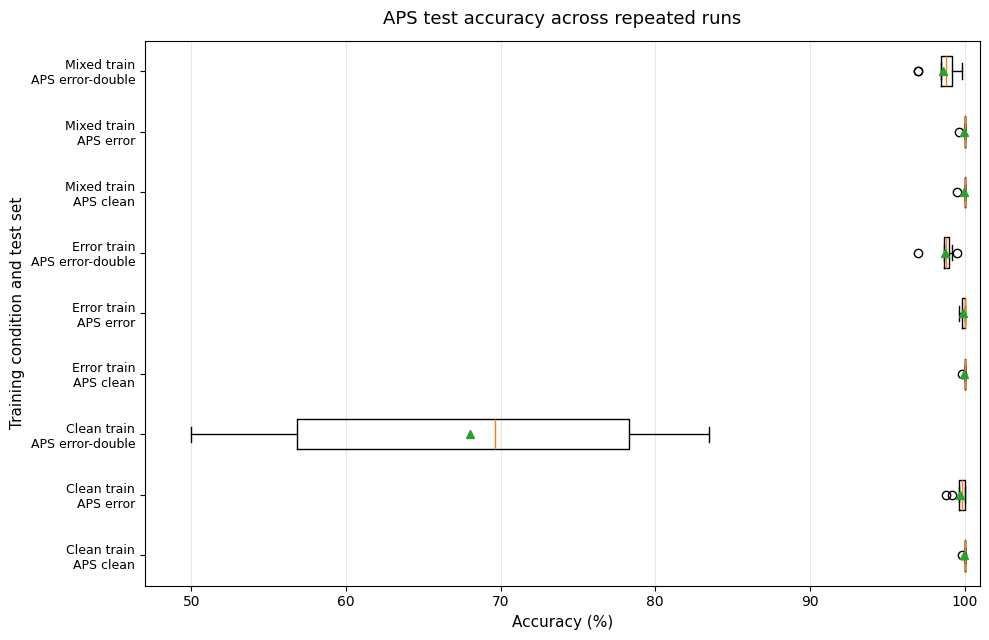

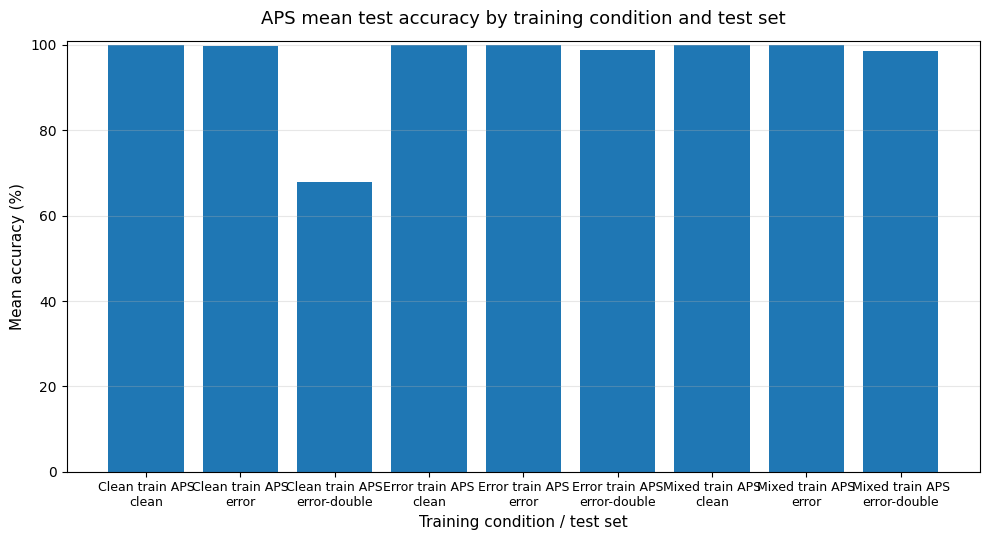

In [6]:
# ============================================================
# CELL 6 — Section 2: APS test results (cleaner version)
# ============================================================

import textwrap

# ---------- helper formatting functions ----------
def short_train_condition(name):
    s = str(name).lower().strip()
    s = s.replace("_trained_xyz", "")
    s = s.replace("_trained", "")
    s = s.replace("clean", "Clean")
    s = s.replace("error", "Error")
    s = s.replace("mixed", "Mixed")
    return s

def short_test_name(name):
    s = str(name).lower().strip()
    mapping = {
        "aps_clean_test": "APS clean",
        "aps_error_test": "APS error",
        "aps_error_double_test": "APS error-double",
        "clean_test": "APS clean",
        "error_test": "APS error",
        "error_double_test": "APS error-double"
    }
    return mapping.get(s, str(name).replace("_", " ").title())

def wrap_label(s, width=18):
    return "\n".join(textwrap.wrap(str(s), width=width))

def clean_group_label(train_name, test_name):
    return f"{short_train_condition(train_name)} train\n{short_test_name(test_name)}"

# ---------- load data ----------
aps_summary = safe_read_csv(PATHS["aps_summary"])
aps_predictions = safe_read_csv(PATHS["aps_predictions"])

if aps_summary is not None:
    aps_summary = standardise_accuracy_column(aps_summary)
    print("APS summary columns:")
    print(list(aps_summary.columns))
    display(aps_summary.head())

    save_table(aps_summary, "section2_aps_test_summary_raw.csv")

    cond_col = get_condition_col(aps_summary)
    run_col = get_run_col(aps_summary)
    test_col = find_column(
        aps_summary,
        ["test_set", "dataset", "test_dataset", "evaluation_set"],
        required=False,
        label="APS test-set column"
    )

    if "accuracy_percent_std" in aps_summary.columns and cond_col is not None and test_col is not None:
        aps_summary["train_short"] = aps_summary[cond_col].apply(short_train_condition)
        aps_summary["test_short"] = aps_summary[test_col].apply(short_test_name)
        aps_summary["plot_group"] = aps_summary.apply(
            lambda r: clean_group_label(r[cond_col], r[test_col]), axis=1
        )

        # summary table
        aps_result_summary = (
            aps_summary.groupby([cond_col, test_col, "train_short", "test_short", "plot_group"])
            .agg(
                mean_accuracy_percent=("accuracy_percent_std", "mean"),
                std_accuracy_percent=("accuracy_percent_std", "std"),
                min_accuracy_percent=("accuracy_percent_std", "min"),
                median_accuracy_percent=("accuracy_percent_std", "median"),
                max_accuracy_percent=("accuracy_percent_std", "max"),
                n_runs=("accuracy_percent_std", "count")
            )
            .reset_index()
            .sort_values(["train_short", "test_short"])
        )

        display(aps_result_summary)
        save_table(aps_result_summary, "section2_aps_test_result_summary.csv")

        # prepare horizontal boxplot to avoid crowded x labels
        ordered_groups = aps_result_summary["plot_group"].tolist()
        box_data = [
            aps_summary.loc[aps_summary["plot_group"] == g, "accuracy_percent_std"].dropna().values
            for g in ordered_groups
        ]

        fig, ax = plt.subplots(figsize=(10, 6.5))
        bp = ax.boxplot(
            box_data,
            vert=False,
            labels=ordered_groups,
            patch_artist=False,
            showmeans=True,
            meanline=False
        )

        ax.set_title("APS test accuracy across repeated runs", fontsize=13, pad=12)
        ax.set_xlabel("Accuracy (%)", fontsize=11)
        ax.set_ylabel("Training condition and test set", fontsize=11)
        ax.grid(axis="x", alpha=0.3)
        ax.set_xlim(
            max(0, np.nanmin(aps_summary["accuracy_percent_std"]) - 3),
            min(101, np.nanmax(aps_summary["accuracy_percent_std"]) + 2)
        )
        ax.tick_params(axis="y", labelsize=9)
        plt.tight_layout()

        save_figure(fig, "figure_aps_test_accuracy_boxplot.png")

        # clean mean-accuracy bar chart
        bar_df = aps_result_summary.copy()
        bar_df["plot_group_wrapped"] = bar_df["plot_group"].apply(lambda x: wrap_label(x, width=16))

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.bar(bar_df["plot_group_wrapped"], bar_df["mean_accuracy_percent"])
        ax.set_title("APS mean test accuracy by training condition and test set", fontsize=13, pad=12)
        ax.set_xlabel("Training condition / test set", fontsize=11)
        ax.set_ylabel("Mean accuracy (%)", fontsize=11)
        ax.set_ylim(0, 101)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", labelrotation=0, labelsize=9)
        plt.tight_layout()

        save_figure(fig, "figure_aps_test_mean_accuracy_bar.png")

# Save AdamW training-status metadata to the appendix export

if PATHS["notebook5_status"].exists():

    with open(PATHS["notebook5_status"], "r") as f:
        notebook5_status = json.load(f)

    print("Notebook 5 training status:")
    print(json.dumps(notebook5_status, indent=2)[:3000])

    with open(
        APPENDIX_DIR / "appendix_05_xyz_only_adamw_training_status.json",
        "w"
    ) as f:
        json.dump(notebook5_status, f, indent=2)

else:
    print("Notebook 5 training-status JSON not found.")

Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final/ycb28_results/pointnetpp_aps_to_ycb28_summary_runs_1_to_9.csv
Shape: (27, 13)


,input_type,training_condition,training_short,n_runs,mean_accuracy_percent,median_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,plot_label
0,XYZ + normals,clean_trained,Clean,9,66.051587,64.464286,4.192099,61.964286,75.000000,XYZ + normals\nClean train
1,XYZ + normals,error_trained,Error,9,67.321429,67.142857,4.576274,58.392857,73.392857,XYZ + normals\nError train
2,XYZ + normals,mixed_trained,Mixed,9,67.182540,66.964286,3.145060,63.392857,72.142857,XYZ + normals\nMixed train
3,XYZ only,clean_trained_xyz,Clean,9,82.936508,83.571429,2.067328,79.464286,86.785714,XYZ only\nClean train
4,XYZ only,error_trained_xyz,Error,9,86.547619,85.357143,2.309378,83.928571,89.821429,XYZ only\nError train
5,XYZ only,mixed_trained_xyz,Mixed,9,89.365079,90.000000,1.862439,85.892857,91.607143,XYZ only\nMixed train


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section3_original_normals_vs_xyz_only_ycb_comparison.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_ycb28_xyz_normals_vs_xyz_only_mean_accuracy.png


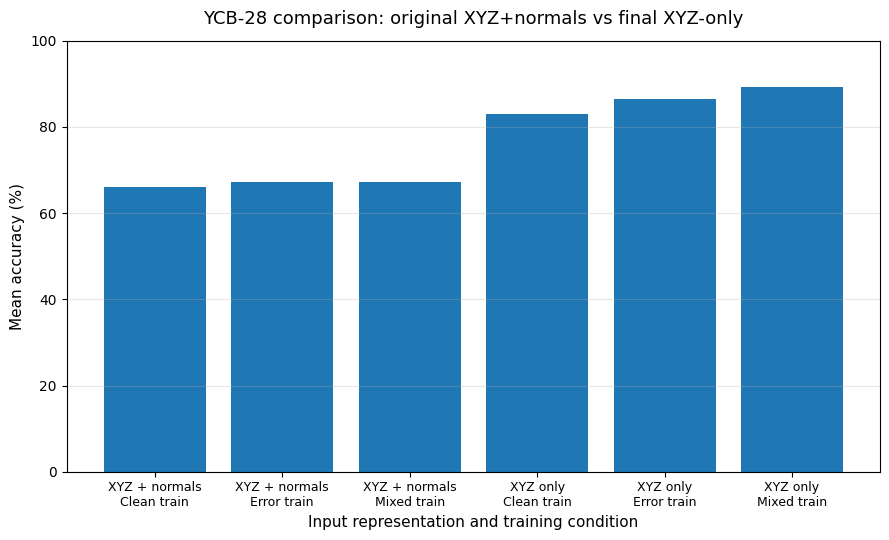

In [7]:
# ============================================================
# CELL 7 — Section 3: Original XYZ + normals vs final XYZ-only comparison
# ============================================================

original_ycb = safe_read_csv(PATHS["original_normals_ycb"])

comparison_rows = []

# ---------- Original XYZ + normals ----------
if original_ycb is not None:
    original_ycb = standardise_accuracy_column(original_ycb)
    cond_col = get_condition_col(original_ycb)

    if "accuracy_percent_std" in original_ycb.columns:
        if cond_col is not None:
            for cond, sub in original_ycb.groupby(cond_col):
                comparison_rows.append({
                    "input_type": "XYZ + normals",
                    "training_condition": cond,
                    "training_short": short_train_condition(cond),
                    "n_runs": len(sub),
                    "mean_accuracy_percent": sub["accuracy_percent_std"].mean(),
                    "median_accuracy_percent": sub["accuracy_percent_std"].median(),
                    "std_accuracy_percent": sub["accuracy_percent_std"].std(),
                    "min_accuracy_percent": sub["accuracy_percent_std"].min(),
                    "max_accuracy_percent": sub["accuracy_percent_std"].max()
                })
        else:
            comparison_rows.append({
                "input_type": "XYZ + normals",
                "training_condition": "all",
                "training_short": "All",
                "n_runs": len(original_ycb),
                "mean_accuracy_percent": original_ycb["accuracy_percent_std"].mean(),
                "median_accuracy_percent": original_ycb["accuracy_percent_std"].median(),
                "std_accuracy_percent": original_ycb["accuracy_percent_std"].std(),
                "min_accuracy_percent": original_ycb["accuracy_percent_std"].min(),
                "max_accuracy_percent": original_ycb["accuracy_percent_std"].max()
            })

# ---------- Final XYZ-only ----------
if ycb_run_accuracy is not None:
    for cond, sub in ycb_run_accuracy.groupby("condition_report"):
        comparison_rows.append({
            "input_type": "XYZ only",
            "training_condition": cond,
            "training_short": short_train_condition(cond),
            "n_runs": len(sub),
            "mean_accuracy_percent": sub["accuracy_percent"].mean(),
            "median_accuracy_percent": sub["accuracy_percent"].median(),
            "std_accuracy_percent": sub["accuracy_percent"].std(),
            "min_accuracy_percent": sub["accuracy_percent"].min(),
            "max_accuracy_percent": sub["accuracy_percent"].max()
        })

input_comparison_df = pd.DataFrame(comparison_rows)

if not input_comparison_df.empty:
    input_comparison_df["plot_label"] = input_comparison_df.apply(
        lambda r: f"{r['input_type']}\n{r['training_short']} train", axis=1
    )

    display(input_comparison_df)
    save_table(input_comparison_df, "section3_original_normals_vs_xyz_only_ycb_comparison.csv")

    # sort in logical order
    order = [
        "XYZ + normals\nClean train",
        "XYZ + normals\nError train",
        "XYZ + normals\nMixed train",
        "XYZ only\nClean train",
        "XYZ only\nError train",
        "XYZ only\nMixed train"
    ]
    input_comparison_df["plot_order"] = input_comparison_df["plot_label"].apply(
        lambda x: order.index(x) if x in order else 999
    )
    plot_df = input_comparison_df.sort_values("plot_order")

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.bar(plot_df["plot_label"], plot_df["mean_accuracy_percent"])
    ax.set_title("YCB-28 comparison: original XYZ+normals vs final XYZ-only", fontsize=13, pad=12)
    ax.set_xlabel("Input representation and training condition", fontsize=11)
    ax.set_ylabel("Mean accuracy (%)", fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelrotation=0, labelsize=9)
    plt.tight_layout()

    save_figure(
        fig,
        "figure_ycb28_xyz_normals_vs_xyz_only_mean_accuracy.png"
    )
else:
    print("No comparison data available.")

ModelNet40 results directory: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/modelnet40_results
Exists: True
ModelNet40 CSV files found:
- results_final_xyz/modelnet40_results/pointnetpp_xyz_modelnet40_subset_mixed_summary_runs.csv
- results_final_xyz/modelnet40_results/pointnetpp_xyz_modelnet40_subset_mixed_predictions_runs.csv
- results_final_xyz/modelnet40_results/modelnet40_subset_all_conditions_summary.csv
- results_final_xyz/modelnet40_results/modelnet40_subset_category_accuracy_all_conditions.csv
- results_final_xyz/modelnet40_results/pointnetpp_xyz_modelnet40_subset_condition_summary.csv
- results_final_xyz/modelnet40_results/modelnet40_subset_category_accuracy.csv
- results_final_xyz/modelnet40_results/modelnet40_subset_mixed_voting_summary.csv
- results_final_xyz/modelnet40_results/modelnet40_subset_mixed_voting_predictions.csv
- results_final_xyz/modelnet40_results/pointnetpp_xyz_modelnet40_subset_all_conditions_summary_runs.csv
- results_final_xyz/modelne

,mapped_class,modelnet40_categories,samples
0,Box-like,"glass_box, xbox, wardrobe, night_stand",226
1,Cylinder-like,"bottle, cup, vase, flower_pot",240
2,Sphere-like proxy,bowl,20
3,Total,9 selected categories,486


,train_condition,n_runs,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,mean_confidence
0,mixed_trained_xyz,9,79.812529,4.436345,69.547325,82.098765,83.539095,0.896854
1,error_trained_xyz,9,72.565158,7.847980,62.139918,73.251029,81.893004,0.879160
2,clean_trained_xyz,9,71.582076,5.017418,61.934156,73.868313,76.337449,0.915746


,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence,votes
0,mixed_trained_xyz,mixed_trained_xyz_run_1_best.pth,80.246914,486,0.879959,10
1,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,84.979424,486,0.883217,10
2,mixed_trained_xyz,mixed_trained_xyz_run_3_best.pth,70.781893,486,0.870067,10
3,mixed_trained_xyz,mixed_trained_xyz_run_4_best.pth,82.304527,486,0.873368,10
4,mixed_trained_xyz,mixed_trained_xyz_run_5_best.pth,80.864198,486,0.869208,10
5,mixed_trained_xyz,mixed_trained_xyz_run_6_best.pth,83.950617,486,0.895320,10
6,mixed_trained_xyz,mixed_trained_xyz_run_7_best.pth,78.600823,486,0.888324,10
7,mixed_trained_xyz,mixed_trained_xyz_run_8_best.pth,84.567901,486,0.856781,10
8,mixed_trained_xyz,mixed_trained_xyz_run_9_best.pth,82.716049,486,0.904341,10


,class_or_group,mean_accuracy_percent,note
0,Box,96.07,Strongest class
1,Cylinder,73.56,Moderate performance
2,Sphere proxy,0.00,Limited by bowl proxy


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section4_modelnet40_subset_mapping.csv
Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section4_modelnet40_singlepass_clean_error_mixed_summary.csv
Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section4_modelnet40_ten_vote_summary.csv
Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section4_modelnet40_classwise_summary.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_modelnet40_clean_error_mixed_mean_accuracy.png
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_modelnet40_classwise_accuracy.png
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_modelnet40_pointnetpp_xyz_modelnet40_subset_mixed_summary_runs.csv
S

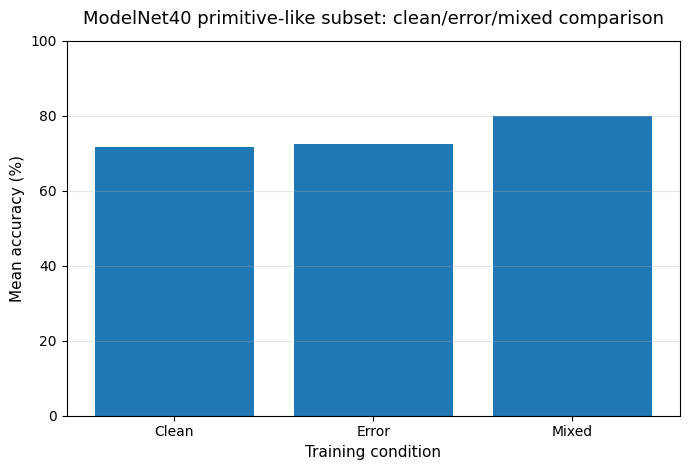

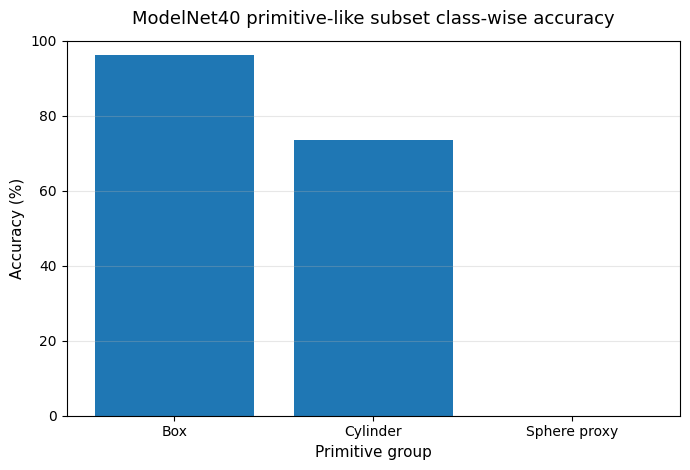

In [8]:
# ============================================================
# CELL 8 — Section 4: ModelNet40 primitive-like subset results
# ============================================================

modelnet_dir = PATHS["modelnet_dir"]

print("ModelNet40 results directory:", modelnet_dir)
print("Exists:", modelnet_dir.exists())

modelnet_csvs = find_csvs(modelnet_dir)
print("ModelNet40 CSV files found:")
for p in modelnet_csvs:
    print("-", p.relative_to(PROJECT_DIR))

modelnet_singlepass = None
modelnet_voting = None
modelnet_predictions = None
modelnet_category = None
modelnet_stats = None

for p in modelnet_csvs:
    s = p.name.lower()

    if modelnet_singlepass is None and ("single" in s or "clean_error_mixed" in s or "condition" in s) and "summary" in s:
        modelnet_singlepass = safe_read_csv(p)

    if modelnet_voting is None and ("vote" in s or "voting" in s or "10" in s) and "summary" in s:
        modelnet_voting = safe_read_csv(p)

    if modelnet_predictions is None and ("prediction" in s or "all_predictions" in s):
        modelnet_predictions = safe_read_csv(p)

    if modelnet_category is None and ("category" in s or "object" in s) and ("accuracy" in s or "summary" in s):
        modelnet_category = safe_read_csv(p)

    if modelnet_stats is None and ("stat" in s or "mann" in s or "kruskal" in s):
        modelnet_stats = safe_read_csv(p)

# fallback tables if needed
if modelnet_singlepass is None:
    modelnet_singlepass = pd.DataFrame([
        {"training_condition": "clean_trained_xyz", "runs": 9, "mean_accuracy_percent": 71.58, "median_accuracy_percent": 73.87, "best_accuracy_percent": 76.34},
        {"training_condition": "error_trained_xyz", "runs": 9, "mean_accuracy_percent": 72.57, "median_accuracy_percent": 73.25, "best_accuracy_percent": 81.89},
        {"training_condition": "mixed_trained_xyz", "runs": 9, "mean_accuracy_percent": 79.81, "median_accuracy_percent": 82.10, "best_accuracy_percent": 83.54}
    ])

if modelnet_voting is None:
    modelnet_voting = pd.DataFrame([
        {"method": "Mixed single-pass", "mean_accuracy_percent": 79.81, "best_accuracy_percent": 83.54},
        {"method": "Mixed 10-vote", "mean_accuracy_percent": 81.00, "best_accuracy_percent": 84.98}
    ])

modelnet_mapping = pd.DataFrame([
    {"mapped_class": "Box-like", "modelnet40_categories": "glass_box, xbox, wardrobe, night_stand", "samples": 226},
    {"mapped_class": "Cylinder-like", "modelnet40_categories": "bottle, cup, vase, flower_pot", "samples": 240},
    {"mapped_class": "Sphere-like proxy", "modelnet40_categories": "bowl", "samples": 20},
    {"mapped_class": "Total", "modelnet40_categories": "9 selected categories", "samples": 486}
])

modelnet_class_summary = pd.DataFrame([
    {"class_or_group": "Box", "mean_accuracy_percent": 96.07, "note": "Strongest class"},
    {"class_or_group": "Cylinder", "mean_accuracy_percent": 73.56, "note": "Moderate performance"},
    {"class_or_group": "Sphere proxy", "mean_accuracy_percent": 0.00, "note": "Limited by bowl proxy"}
])

display(modelnet_mapping)
display(modelnet_singlepass)
display(modelnet_voting)
display(modelnet_class_summary)

save_table(modelnet_mapping, "section4_modelnet40_subset_mapping.csv")
save_table(modelnet_singlepass, "section4_modelnet40_singlepass_clean_error_mixed_summary.csv")
save_table(modelnet_voting, "section4_modelnet40_ten_vote_summary.csv")
save_table(modelnet_class_summary, "section4_modelnet40_classwise_summary.csv")

# ---------- Figure 1: clean/error/mixed single-pass ----------
single_df = modelnet_singlepass.copy()
cond_col = find_column(single_df, ["training_condition", "condition", "train_condition"], required=False)
mean_col = find_column(single_df, ["mean_accuracy_percent", "accuracy_percent"], required=False)

if cond_col is not None and mean_col is not None:
    single_df["condition_short"] = single_df[cond_col].apply(short_train_condition)
    order_map = {"Clean": 0, "Error": 1, "Mixed": 2}
    single_df["plot_order"] = single_df["condition_short"].map(order_map)
    single_df = single_df.sort_values("plot_order")

    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.bar(single_df["condition_short"], single_df[mean_col])
    ax.set_title("ModelNet40 primitive-like subset: clean/error/mixed comparison", fontsize=13, pad=12)
    ax.set_xlabel("Training condition", fontsize=11)
    ax.set_ylabel("Mean accuracy (%)", fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    save_figure(fig, "figure_modelnet40_clean_error_mixed_mean_accuracy.png")

# ---------- Figure 2: mixed single-pass vs 10-vote ----------
vote_df = modelnet_voting.copy()
method_col = find_column(vote_df, ["method"], required=False)
vote_mean_col = find_column(vote_df, ["mean_accuracy_percent", "accuracy_percent"], required=False)

if method_col is not None and vote_mean_col is not None:
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.bar(vote_df[method_col], vote_df[vote_mean_col])
    ax.set_title("ModelNet40 mixed evaluation: single-pass vs 10-vote", fontsize=13, pad=12)
    ax.set_xlabel("Evaluation method", fontsize=11)
    ax.set_ylabel("Mean accuracy (%)", fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelrotation=0, labelsize=10)
    plt.tight_layout()

    save_figure(fig, "figure_modelnet40_mixed_singlepass_vs_10vote.png")

# ---------- Figure 3: class-wise accuracy ----------
class_df = modelnet_class_summary.copy()
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.bar(class_df["class_or_group"], class_df["mean_accuracy_percent"])
ax.set_title("ModelNet40 primitive-like subset class-wise accuracy", fontsize=13, pad=12)
ax.set_xlabel("Primitive group", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

save_figure(fig, "figure_modelnet40_classwise_accuracy.png")

# appendix backup for all found modelnet csvs
for p in modelnet_csvs:
    try:
        df = pd.read_csv(p)
        safe_name = "appendix_modelnet40_" + p.name
        save_appendix_table(df, safe_name)
    except Exception:
        pass

Running corrected Cell 9: Final RProp hybrid comparison
Final RProp summary path: /content/gdrive/MyDrive/PointNet_APS_Project_V2/RPROP_OPTIMIZER_COMPARISON/version_3_final_hybrid/results/ycb28_results/rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv
Exists: True
Loaded final RProp summary:
Shape: (10, 7)


,optimizer,version,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence
0,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_10_best.pth,68.750000,560,0.770237
1,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_1_best.pth,71.607143,560,0.781387
2,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_2_best.pth,69.107143,560,0.778383
3,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_3_best.pth,71.607143,560,0.801896
4,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_4_best.pth,70.357143,560,0.820236


,optimizer,version,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence,method
0,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_10_best.pth,68.750000,560,0.770237,RProp mixed
1,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_1_best.pth,71.607143,560,0.781387,RProp mixed
2,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_2_best.pth,69.107143,560,0.778383,RProp mixed
3,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_3_best.pth,71.607143,560,0.801896,RProp mixed
4,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_4_best.pth,70.357143,560,0.820236,RProp mixed
5,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_5_best.pth,71.428571,560,0.801963,RProp mixed
6,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_6_best.pth,72.857143,560,0.806592,RProp mixed
7,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_7_best.pth,72.142857,560,0.781126,RProp mixed
8,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_8_best.pth,71.964286,560,0.773172,RProp mixed
9,RProp,v3_final_hybrid,mixed_trained_xyz_rprop_v3,mixed_trained_xyz_rprop_v3_run_9_best.pth,72.142857,560,0.780285,RProp mixed


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section5_rprop_final_run_level_ycb28_accuracy.csv


,method,n,min_accuracy_percent,q1_accuracy_percent,median_accuracy_percent,q3_accuracy_percent,max_accuracy_percent,mean_accuracy_percent,std_accuracy_percent
0,RProp mixed,10,68.75,70.625,71.607143,72.098214,72.857143,71.196429,1.357482


...

Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section5_adamw_vs_rprop_final_classwise_summary.csv


,method,accuracy_percent
0,AdamW mixed,91.071429
1,AdamW mixed,91.607143
2,AdamW mixed,87.321429
3,AdamW mixed,85.892857
4,AdamW mixed,90.000000
5,AdamW mixed,90.535714
6,AdamW mixed,89.642857
7,AdamW mixed,88.214286
8,AdamW mixed,90.000000
9,RProp mixed,68.750000


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section5_adamw_vs_rprop_final_run_level_accuracy.csv


,method,runs,mean_accuracy_percent,median_accuracy_percent,best_accuracy_percent,min_accuracy_percent,std_accuracy_percent
0,AdamW mixed,9,89.365079,90.000000,91.607143,85.892857,1.862439
1,RProp mixed,10,71.196429,71.607143,72.857143,68.750000,1.357482


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section5_adamw_vs_rprop_final_summary.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_ycb28_adamw_vs_rprop_final_boxplot.png
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_ycb28_adamw_vs_rprop_final_mean_accuracy.png
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_rprop_final_ycb28_classwise_accuracy.png

Corrected Cell 9 complete.
Final RProp mean accuracy should now be about 71.20%, not 70.71%.


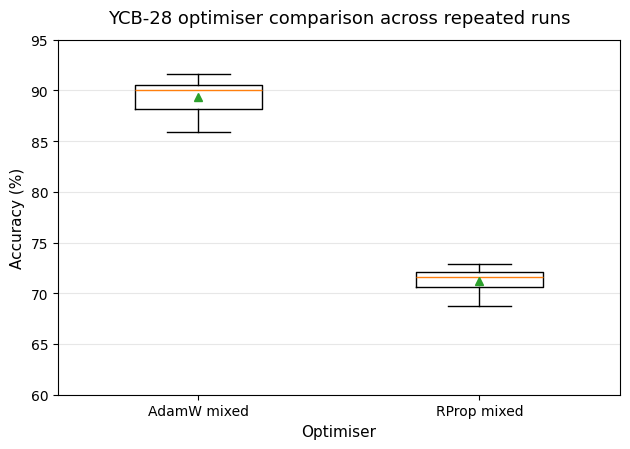

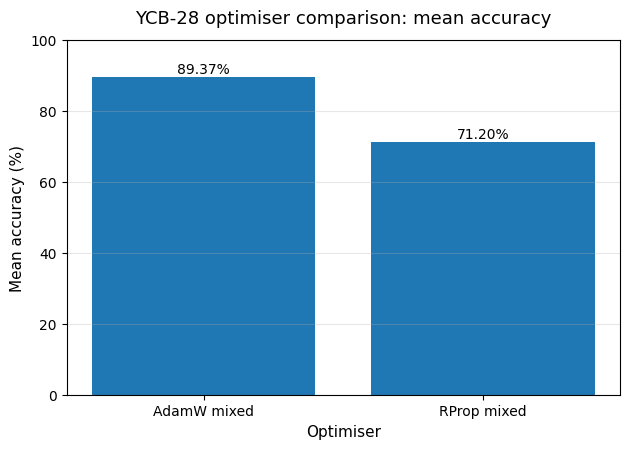

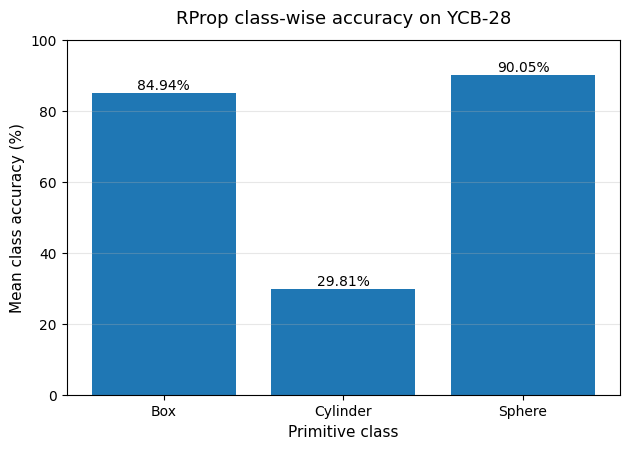

In [9]:
# ============================================================
# CELL 9 — Section 5: RProp optimiser comparison
# Corrected version: force final hybrid RProp file only
# ============================================================

print("Running corrected Cell 9: Final RProp hybrid comparison")

# ------------------------------------------------------------
# 1. Force correct final RProp files
# ------------------------------------------------------------

RPROP_FINAL_SUMMARY_PATH = (
    PROJECT_DIR
    / "RPROP_OPTIMIZER_COMPARISON"
    / "version_3_final_hybrid"
    / "results"
    / "ycb28_results"
    / "rprop_v3_mixed_xyz_ycb28_summary_runs_1_to_10.csv"
)

RPROP_FINAL_CLASSWISE_PATH = (
    PROJECT_DIR
    / "RPROP_OPTIMIZER_COMPARISON"
    / "version_3_final_hybrid"
    / "tables"
    / "rprop_v3_mixed_ycb28_classwise_accuracy.csv"
)

RPROP_FINAL_FIVE_NUMBER_PATH = (
    PROJECT_DIR
    / "RPROP_OPTIMIZER_COMPARISON"
    / "version_3_final_hybrid"
    / "tables"
    / "rprop_v3_mixed_ycb28_five_number_summary.csv"
)

print("Final RProp summary path:", RPROP_FINAL_SUMMARY_PATH)
print("Exists:", RPROP_FINAL_SUMMARY_PATH.exists())

if not RPROP_FINAL_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        "Final RProp hybrid summary file not found. "
        "Check the version_3_final_hybrid folder path."
    )

# ------------------------------------------------------------
# 2. Load final RProp run-level results
# ------------------------------------------------------------

rprop_run_accuracy = pd.read_csv(RPROP_FINAL_SUMMARY_PATH)

print("Loaded final RProp summary:")
print("Shape:", rprop_run_accuracy.shape)
display(rprop_run_accuracy.head())

rprop_acc_col = find_column(
    rprop_run_accuracy,
    ["accuracy_percent", "test_accuracy_percent", "ycb_accuracy", "accuracy"],
    required=True,
    label="RProp accuracy"
)

rprop_run_accuracy = rprop_run_accuracy.copy()
rprop_run_accuracy["accuracy_percent"] = pd.to_numeric(
    rprop_run_accuracy[rprop_acc_col],
    errors="coerce"
)

if rprop_run_accuracy["accuracy_percent"].dropna().max() <= 1.5:
    rprop_run_accuracy["accuracy_percent"] *= 100.0

# Report-facing label: do not use version wording
rprop_run_accuracy["method"] = "RProp mixed"

# Save corrected run-level table
display(rprop_run_accuracy)
save_table(
    rprop_run_accuracy,
    "section5_rprop_final_run_level_ycb28_accuracy.csv"
)

# ------------------------------------------------------------
# 3. RProp five-number summary
# ------------------------------------------------------------

rprop_stats = five_number_summary(rprop_run_accuracy["accuracy_percent"])

rprop_stats_df = pd.DataFrame([{
    "method": "RProp mixed",
    "n": rprop_stats["n"],
    "min_accuracy_percent": rprop_stats["min"],
    "q1_accuracy_percent": rprop_stats["q1"],
    "median_accuracy_percent": rprop_stats["median"],
    "q3_accuracy_percent": rprop_stats["q3"],
    "max_accuracy_percent": rprop_stats["max"],
    "mean_accuracy_percent": rprop_stats["mean"],
    "std_accuracy_percent": rprop_stats["std"]
}])

display(rprop_stats_df)
save_table(
    rprop_stats_df,
    "section5_rprop_final_five_number_summary.csv"
)

# ------------------------------------------------------------
# 4. Load or recreate class-wise AdamW vs RProp comparison
# ------------------------------------------------------------

if RPROP_FINAL_CLASSWISE_PATH.exists():
    rprop_class_raw = pd.read_csv(RPROP_FINAL_CLASSWISE_PATH)
    print("Loaded final RProp class-wise file:")
    print(rprop_class_raw.columns)
    display(rprop_class_raw)

# Build class-wise comparison directly from the final RProp result file

if RPROP_FINAL_CLASSWISE_PATH.exists():

    rprop_class_raw = pd.read_csv(RPROP_FINAL_CLASSWISE_PATH)

    class_name_map = {
        "box": "Box",
        "cylinder": "Cylinder",
        "sphere": "Sphere"
    }

    adamw_class_accuracy = {
        "Box": 88.70,
        "Cylinder": 87.36,
        "Sphere": 90.91
    }

    rprop_class_summary = rprop_class_raw[
        ["true_primitive", "mean_accuracy_percent"]
    ].copy()

    rprop_class_summary["class"] = (
        rprop_class_summary["true_primitive"]
        .astype(str)
        .str.lower()
        .map(class_name_map)
    )

    rprop_class_summary["adamw_mixed_mean_accuracy_percent"] = (
        rprop_class_summary["class"].map(adamw_class_accuracy)
    )

    rprop_class_summary = rprop_class_summary.rename(
        columns={
            "mean_accuracy_percent": "rprop_mean_accuracy_percent"
        }
    )

    rprop_class_summary = rprop_class_summary[
        [
            "class",
            "adamw_mixed_mean_accuracy_percent",
            "rprop_mean_accuracy_percent"
        ]
    ]

    display(rprop_class_summary)

    save_table(
        rprop_class_summary,
        "section5_adamw_vs_rprop_final_classwise_summary.csv"
    )

else:
    raise FileNotFoundError(
        f"RProp class-wise result file not found: {RPROP_FINAL_CLASSWISE_PATH}"
    )

# ------------------------------------------------------------
# 5. AdamW mixed vs final RProp comparison
# ------------------------------------------------------------

if ycb_run_accuracy is None:
    raise ValueError(
        "ycb_run_accuracy is missing. Run Cell 5 before this corrected Cell 9."
    )

adamw_mixed_runs = ycb_run_accuracy[
    ycb_run_accuracy["condition_report"]
    .astype(str)
    .str.lower()
    .str.contains("mixed")
].copy()

adamw_mixed_runs["method"] = "AdamW mixed"
adamw_mixed_runs = adamw_mixed_runs[["method", "accuracy_percent"]]

rprop_for_plot = rprop_run_accuracy[["method", "accuracy_percent"]].copy()

optimiser_plot_df = pd.concat(
    [adamw_mixed_runs, rprop_for_plot],
    ignore_index=True
)

display(optimiser_plot_df)
save_table(
    optimiser_plot_df,
    "section5_adamw_vs_rprop_final_run_level_accuracy.csv"
)

optimiser_summary = (
    optimiser_plot_df.groupby("method")
    .agg(
        runs=("accuracy_percent", "count"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        median_accuracy_percent=("accuracy_percent", "median"),
        best_accuracy_percent=("accuracy_percent", "max"),
        min_accuracy_percent=("accuracy_percent", "min"),
        std_accuracy_percent=("accuracy_percent", "std")
    )
    .reset_index()
)

display(optimiser_summary)
save_table(
    optimiser_summary,
    "section5_adamw_vs_rprop_final_summary.csv"
)

# ------------------------------------------------------------
# 6. Clean figure: AdamW vs RProp box plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.4, 4.6))

groups = ["AdamW mixed", "RProp mixed"]
data = [
    optimiser_plot_df.loc[
        optimiser_plot_df["method"] == g,
        "accuracy_percent"
    ].dropna().values
    for g in groups
]

ax.boxplot(
    data,
    labels=groups,
    showmeans=True,
    widths=0.45
)

ax.set_title(
    "YCB-28 optimiser comparison across repeated runs",
    fontsize=13,
    pad=12
)
ax.set_xlabel("Optimiser", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(60, 95)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_figure(
    fig,
    "figure_ycb28_adamw_vs_rprop_final_boxplot.png"
)

# ------------------------------------------------------------
# 7. Clean figure: AdamW vs RProp mean accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.4, 4.6))

ax.bar(
    optimiser_summary["method"],
    optimiser_summary["mean_accuracy_percent"]
)

ax.set_title(
    "YCB-28 optimiser comparison: mean accuracy",
    fontsize=13,
    pad=12
)
ax.set_xlabel("Optimiser", fontsize=11)
ax.set_ylabel("Mean accuracy (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(optimiser_summary["mean_accuracy_percent"]):
    ax.text(
        i,
        v + 1.2,
        f"{v:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
save_figure(
    fig,
    "figure_ycb28_adamw_vs_rprop_final_mean_accuracy.png"
)

# ------------------------------------------------------------
# 8. Clean figure: RProp class-wise result
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.4, 4.6))

ax.bar(
    rprop_class_summary["class"],
    rprop_class_summary["rprop_mean_accuracy_percent"]
)

ax.set_title(
    "RProp class-wise accuracy on YCB-28",
    fontsize=13,
    pad=12
)
ax.set_xlabel("Primitive class", fontsize=11)
ax.set_ylabel("Mean class accuracy (%)", fontsize=11)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)

for i, v in enumerate(rprop_class_summary["rprop_mean_accuracy_percent"]):
    ax.text(
        i,
        v + 1.2,
        f"{v:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
save_figure(
    fig,
    "figure_rprop_final_ycb28_classwise_accuracy.png"
)

print("\nCorrected Cell 9 complete.")
print("Final RProp mean accuracy should now be about 71.20%, not 70.71%.")

In [10]:
# ============================================================
# CELL 10 — Section 6: Corrected statistical tests
# Corrected version: force proper run-level ModelNet40 file
# ============================================================

print("Running corrected Cell 10: Statistical tests")

all_stats_tables = []

# ------------------------------------------------------------
# Helper: clean condition names
# ------------------------------------------------------------

def clean_condition_name(x):
    s = str(x).lower().strip()
    s = s.replace("_trained_xyz", "")
    s = s.replace("_trained", "")
    s = s.replace("trained_", "")
    s = s.replace("_xyz", "")

    if "clean" in s:
        return "clean"
    if "error" in s:
        return "error"
    if "mixed" in s:
        return "mixed"

    return s

# ------------------------------------------------------------
# 6A. YCB-28 AdamW clean/error/mixed tests
# ------------------------------------------------------------

if ycb_run_accuracy is None:
    raise ValueError(
        "ycb_run_accuracy is missing. Run Cell 5 before this corrected Cell 10."
    )

ycb_stats_df = ycb_run_accuracy.copy()
ycb_stats_df["condition_clean"] = ycb_stats_df["condition_report"].apply(clean_condition_name)

print("YCB-28 groups:", ycb_stats_df["condition_clean"].unique())

ycb_kruskal = kruskal_test(
    ycb_stats_df,
    "condition_clean",
    "accuracy_percent",
    label="YCB-28 AdamW clean/error/mixed"
)

ycb_pairwise = pairwise_mannwhitney(
    ycb_stats_df,
    "condition_clean",
    "accuracy_percent",
    comparisons=[
        ("clean", "error"),
        ("clean", "mixed"),
        ("error", "mixed")
    ],
    label="YCB-28 AdamW clean/error/mixed"
)

display(ycb_kruskal)
display(ycb_pairwise)

save_table(
    ycb_kruskal,
    "section6_ycb28_adamw_kruskal_wallis_corrected.csv"
)
save_table(
    ycb_pairwise,
    "section6_ycb28_adamw_pairwise_mannwhitney_corrected.csv"
)

all_stats_tables += [ycb_kruskal, ycb_pairwise]



# ------------------------------------------------------------
# 6B. AdamW mixed vs final RProp tests
# Uses corrected final RProp from Cell 9
# ------------------------------------------------------------

if "rprop_run_accuracy" not in globals():
    raise ValueError(
        "rprop_run_accuracy is missing. Run corrected Cell 9 before this corrected Cell 10."
    )

adamw_mixed = ycb_run_accuracy[
    ycb_run_accuracy["condition_report"]
    .astype(str)
    .str.lower()
    .str.contains("mixed")
].copy()

adamw_mixed["method"] = "AdamW mixed"
adamw_mixed = adamw_mixed[["method", "accuracy_percent"]]

rprop_method_df = rprop_run_accuracy[["method", "accuracy_percent"]].copy()

adamw_vs_rprop = pd.concat(
    [adamw_mixed, rprop_method_df],
    ignore_index=True
)

display(adamw_vs_rprop)

adamw_rprop_mw = pairwise_mannwhitney(
    adamw_vs_rprop,
    "method",
    "accuracy_percent",
    comparisons=[
        ("AdamW mixed", "RProp mixed")
    ],
    label="YCB-28 AdamW vs RProp"
)

display(adamw_rprop_mw)

save_table(
    adamw_vs_rprop,
    "section6_ycb28_adamw_vs_rprop_run_level_for_statistics_corrected.csv"
)
save_table(
    adamw_rprop_mw,
    "section6_ycb28_adamw_vs_rprop_mannwhitney_corrected.csv"
)

all_stats_tables.append(adamw_rprop_mw)

# ------------------------------------------------------------
# 6C. Combined statistics summary
# ------------------------------------------------------------

combined_stats = pd.concat(
    [df for df in all_stats_tables if df is not None and not df.empty],
    ignore_index=True
)

display(combined_stats)

save_table(
    combined_stats,
    "section6_combined_statistical_tests_summary_corrected.csv"
)

save_appendix_table(
    combined_stats,
    "appendix_combined_statistical_tests_full_corrected.csv"
)

print("\nCorrected Cell 10 complete.")
print("Check that ModelNet40 statistics now use 9 runs per condition.")

Running corrected Cell 10: Statistical tests
YCB-28 groups: ['clean' 'error' 'mixed']


,test_set,groups,kruskal_h,p_value,significant_0.05
0,YCB-28 AdamW clean/error/mixed,"clean, error, mixed",17.898397,0.00013,True


,test_set,comparison,group_a,group_b,n_a,n_b,mean_a,mean_b,median_a,median_b,mann_whitney_u,p_value,cliffs_delta_a_minus_b,holm_rank,holm_adjusted_p,significant_0.05
0,YCB-28 AdamW clean/error/mixed,clean vs mixed,clean,mixed,9,9,82.936508,89.365079,83.571429,90.000000,1.0,0.000562,-0.975309,1,0.001687,True
1,YCB-28 AdamW clean/error/mixed,clean vs error,clean,error,9,9,82.936508,86.547619,83.571429,85.357143,6.0,0.002639,-0.851852,2,0.005278,True
2,YCB-28 AdamW clean/error/mixed,error vs mixed,error,mixed,9,9,86.547619,89.365079,85.357143,90.000000,12.0,0.013323,-0.703704,3,0.013323,True


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section6_ycb28_adamw_kruskal_wallis_corrected.csv
Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section6_ycb28_adamw_pairwise_mannwhitney_corrected.csv


,method,accuracy_percent
0,AdamW mixed,91.071429
1,AdamW mixed,91.607143
2,AdamW mixed,87.321429
3,AdamW mixed,85.892857
4,AdamW mixed,90.000000
5,AdamW mixed,90.535714
6,AdamW mixed,89.642857
7,AdamW mixed,88.214286
8,AdamW mixed,90.000000
9,RProp mixed,68.750000


,test_set,comparison,group_a,group_b,n_a,n_b,mean_a,mean_b,median_a,median_b,mann_whitney_u,p_value,cliffs_delta_a_minus_b,holm_rank,holm_adjusted_p,significant_0.05
0,YCB-28 AdamW vs RProp,AdamW mixed vs RProp mixed,AdamW mixed,RProp mixed,9,10,89.365079,71.196429,90.0,71.607143,90.0,0.000275,1.0,1,0.000275,True


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section6_ycb28_adamw_vs_rprop_run_level_for_statistics_corrected.csv
Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section6_ycb28_adamw_vs_rprop_mannwhitney_corrected.csv


,test_set,groups,kruskal_h,p_value,significant_0.05,comparison,group_a,group_b,n_a,n_b,mean_a,mean_b,median_a,median_b,mann_whitney_u,cliffs_delta_a_minus_b,holm_rank,holm_adjusted_p
0,YCB-28 AdamW clean/error/mixed,"clean, error, mixed",17.898397,0.000130,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YCB-28 AdamW clean/error/mixed,NaN,NaN,0.000562,True,clean vs mixed,clean,mixed,9.0,9.0,82.936508,89.365079,83.571429,90.000000,1.0,-0.975309,1.0,0.001687
2,YCB-28 AdamW clean/error/mixed,NaN,NaN,0.002639,True,clean vs error,clean,error,9.0,9.0,82.936508,86.547619,83.571429,85.357143,6.0,-0.851852,2.0,0.005278
3,YCB-28 AdamW clean/error/mixed,NaN,NaN,0.013323,True,error vs mixed,error,mixed,9.0,9.0,86.547619,89.365079,85.357143,90.000000,12.0,-0.703704,3.0,0.013323
4,YCB-28 AdamW vs RProp,NaN,NaN,0.000275,True,AdamW mixed vs RProp mixed,AdamW mixed,RProp mixed,9.0,10.0,89.365079,71.196429,90.000000,71.607143,90.0,1.000000,1.0,0.000275


Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables/section6_combined_statistical_tests_summary_corrected.csv
Saved appendix table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_combined_statistical_tests_full_corrected.csv

Corrected Cell 10 complete.
Check that ModelNet40 statistics now use 9 runs per condition.


Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_overall_experimental_workflow.png


PosixPath('/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_overall_experimental_workflow.png')

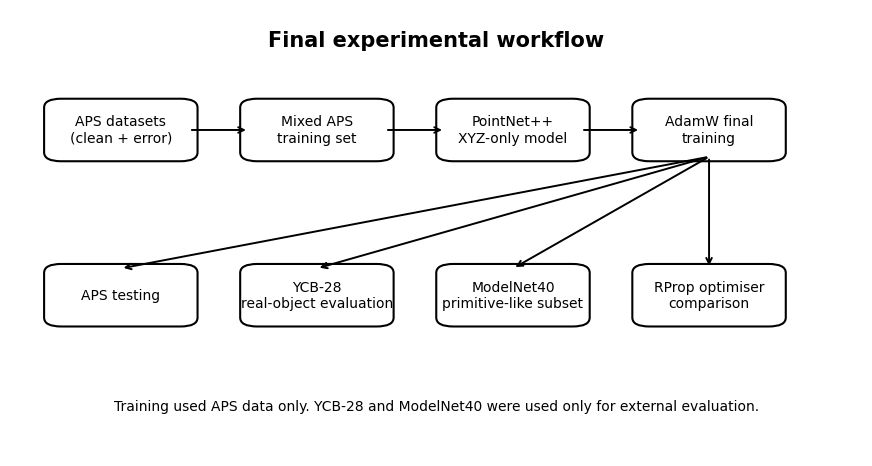

In [11]:
# ============================================================
# CELL 11 — Section 7A: Workflow diagram
# ============================================================

from matplotlib.patches import FancyBboxPatch

def draw_workflow_diagram():
    fig, ax = plt.subplots(figsize=(11, 5.8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    def add_box(x, y, w, h, text, fontsize=10):
        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

    def add_arrow(x1, y1, x2, y2):
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", lw=1.4)
        )

    # top row
    top_y = 0.67
    w = 0.16
    h = 0.12
    xs_top = [0.05, 0.28, 0.51, 0.74]

    top_labels = [
        "APS datasets\n(clean + error)",
        "Mixed APS\ntraining set",
        "PointNet++\nXYZ-only model",
        "AdamW final\ntraining"
    ]

    for x, label in zip(xs_top, top_labels):
        add_box(x, top_y, w, h, label, fontsize=10)

    # top row arrows
    add_arrow(xs_top[0] + w, top_y + h/2, xs_top[1], top_y + h/2)
    add_arrow(xs_top[1] + w, top_y + h/2, xs_top[2], top_y + h/2)
    add_arrow(xs_top[2] + w, top_y + h/2, xs_top[3], top_y + h/2)

    # bottom row
    bot_y = 0.30
    xs_bot = [0.05, 0.28, 0.51, 0.74]
    bot_labels = [
        "APS testing",
        "YCB-28\nreal-object evaluation",
        "ModelNet40\nprimitive-like subset",
        "RProp optimiser\ncomparison"
    ]

    for x, label in zip(xs_bot, bot_labels):
        add_box(x, bot_y, w, h, label, fontsize=10)

    # arrows from final model/training to evaluation branches
    for xb in xs_bot:
        add_arrow(xs_top[3] + w/2, top_y, xb + w/2, bot_y + h)

    ax.text(
        0.5, 0.93,
        "Final experimental workflow",
        ha="center", va="center",
        fontsize=15, fontweight="bold"
    )

    ax.text(
        0.5, 0.11,
        "Training used APS data only. YCB-28 and ModelNet40 were used only for external evaluation.",
        ha="center", va="center",
        fontsize=10
    )

    return fig

workflow_fig = draw_workflow_diagram()
save_figure(workflow_fig, "figure_overall_experimental_workflow.png")

Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_pointnetpp_simplified_architecture.png


PosixPath('/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/figure_pointnetpp_simplified_architecture.png')

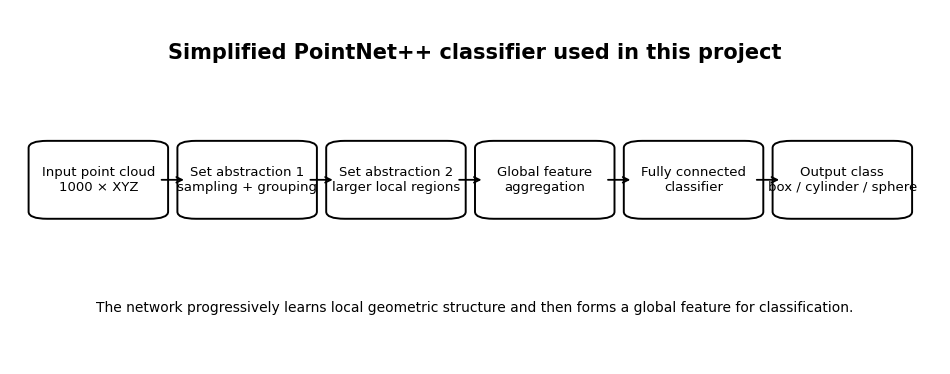

In [12]:
# ============================================================
# CELL 12 — Section 7B: Simplified PointNet++ architecture diagram
# ============================================================

from matplotlib.patches import FancyBboxPatch

def draw_pointnetpp_diagram():
    fig, ax = plt.subplots(figsize=(12, 4.6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    def add_box(x, y, w, h, text, fontsize=9.5):
        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.01,rounding_size=0.02",
            fill=False,
            linewidth=1.4
        )
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

    def add_arrow(x1, y1, x2, y2):
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", lw=1.3)
        )

    y = 0.42
    h = 0.20
    w = 0.13
    xs = [0.03, 0.19, 0.35, 0.51, 0.67, 0.83]

    labels = [
        "Input point cloud\n1000 × XYZ",
        "Set abstraction 1\nsampling + grouping",
        "Set abstraction 2\nlarger local regions",
        "Global feature\naggregation",
        "Fully connected\nclassifier",
        "Output class\nbox / cylinder / sphere"
    ]

    for x, label in zip(xs, labels):
        add_box(x, y, w, h, label)

    for i in range(len(xs) - 1):
        add_arrow(xs[i] + w, y + h/2, xs[i+1], y + h/2)

    ax.text(
        0.5, 0.88,
        "Simplified PointNet++ classifier used in this project",
        ha="center", va="center",
        fontsize=15, fontweight="bold"
    )

    ax.text(
        0.5, 0.16,
        "The network progressively learns local geometric structure and then forms a global feature for classification.",
        ha="center", va="center",
        fontsize=10
    )

    return fig

pointnet_fig = draw_pointnetpp_diagram()
save_figure(pointnet_fig, "figure_pointnetpp_simplified_architecture.png")

In [13]:
# ============================================================
# CELL 13 — Point-cloud visualisation helper functions
# ============================================================

def load_pointcloud_csv(path, nmax=2000):
    path = Path(path)

    arr = pd.read_csv(path, header=None).values

    # Some files may contain headers. Retry with default header handling.
    if arr.shape[1] < 3:
        arr = pd.read_csv(path).values

    if arr.shape[1] < 3:
        raise ValueError(f"Point cloud file has fewer than 3 columns: {path}")

    xyz = arr[:, :3].astype(float)
    xyz = xyz[np.all(np.isfinite(xyz), axis=1)]

    if len(xyz) > nmax:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(xyz), size=nmax, replace=False)
        xyz = xyz[idx]

    return xyz


def plot_single_pointcloud(ax, xyz, title):
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=2)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    try:
        max_range = (xyz.max(axis=0) - xyz.min(axis=0)).max() / 2.0
        mid = xyz.mean(axis=0)

        ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
        ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
        ax.set_zlim(mid[2] - max_range, mid[2] + max_range)
    except Exception:
        pass


def find_pointcloud_files(keyword_groups, root):
    root = Path(root)
    files = list(root.rglob("*.csv"))

    selected = []

    for keywords in keyword_groups:
        match = None

        for p in files:
            s = str(p).lower()

            if all(k.lower() in s for k in keywords):
                match = p
                break

        selected.append(match)

    return selected


print("Point-cloud helper functions ready.")

Point-cloud helper functions ready.


APS example files:
APS clean box -> data/generated/aps_clean_test_style/boxes/boxe_0000.csv
APS clean cylinder -> data/generated/aps_clean_test_style/cylinders/cylinder_0000.csv
APS clean sphere -> data/generated/aps_clean_test_style/spheres/sphere_0000.csv
APS error box -> data/generated/aps_error_double_test_style/boxes/boxe_0000.csv
APS error cylinder -> data/generated/aps_error_double_test_style/cylinders/cylinder_0000.csv
APS error sphere -> data/generated/aps_error_double_test_style/spheres/sphere_0000.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/pointcloud_visualisations/figure_aps_clean_error_pointcloud_examples.png


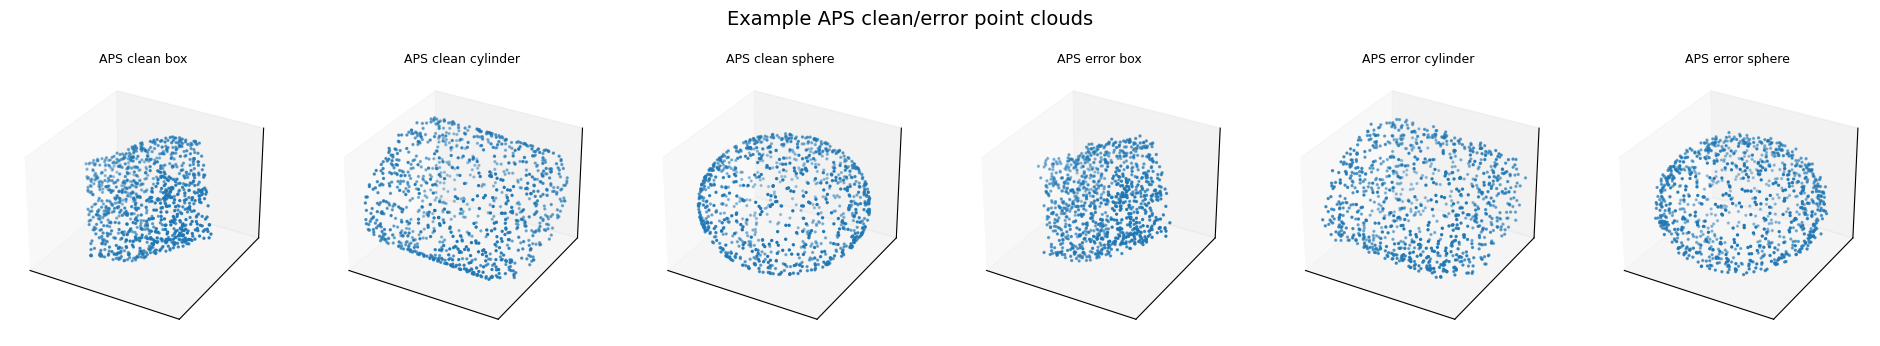

In [14]:
# ============================================================
# CELL 14 — Section 7C: APS clean/error point-cloud examples
# ============================================================

aps_root = PROJECT_DIR / "data"

aps_examples = find_pointcloud_files(
    [
        ["clean", "box"],
        ["clean", "cylinder"],
        ["clean", "sphere"],
        ["error", "box"],
        ["error", "cylinder"],
        ["error", "sphere"],
    ],
    aps_root
)

example_labels = [
    "APS clean box",
    "APS clean cylinder",
    "APS clean sphere",
    "APS error box",
    "APS error cylinder",
    "APS error sphere"
]

print("APS example files:")
for label, p in zip(example_labels, aps_examples):
    print(label, "->", p.relative_to(PROJECT_DIR) if p else "not found")

valid_examples = [
    (label, p)
    for label, p in zip(example_labels, aps_examples)
    if p is not None
]

if valid_examples:
    n = len(valid_examples)
    fig = plt.figure(figsize=(4 * n, 4))

    for i, (label, p) in enumerate(valid_examples, 1):
        ax = fig.add_subplot(1, n, i, projection="3d")
        xyz = load_pointcloud_csv(p)
        plot_single_pointcloud(ax, xyz, label)

    fig.suptitle("Example APS clean/error point clouds", fontsize=14)

    path = POINTCLOUD_DIR / "figure_aps_clean_error_pointcloud_examples.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
else:
    print("No APS examples found automatically. You may manually select CSV files from data/generated.")

Loaded: /content/gdrive/MyDrive/PointNet_APS_Project_V2/metadata/ycb28_pointcloud_manifest_bbox_norm.csv
Shape: (560, 10)
YCB manifest columns:
['path', 'object_name', 'class_name', 'label', 'sample_id', 'variant', 'role', 'source_mesh', 'source_type', 'n_points']


,path,object_name,class_name,label,sample_id,variant,role,source_mesh,source_type,n_points
0,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,0,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
1,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,1,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
2,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,2,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
3,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,3,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000
4,/content/drive/MyDrive/PointNet_APS_Project_V2...,003_cracker_box,box,0,4,ycb28,ycb28_test,/content/drive/MyDrive/PointNet_APS_Project_V2...,official_ycb_download,1000


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/pointcloud_visualisations/figure_ycb28_pointcloud_examples.png
Saved appendix point-cloud grid: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix/appendix_ycb28_all_object_pointcloud_grid.png


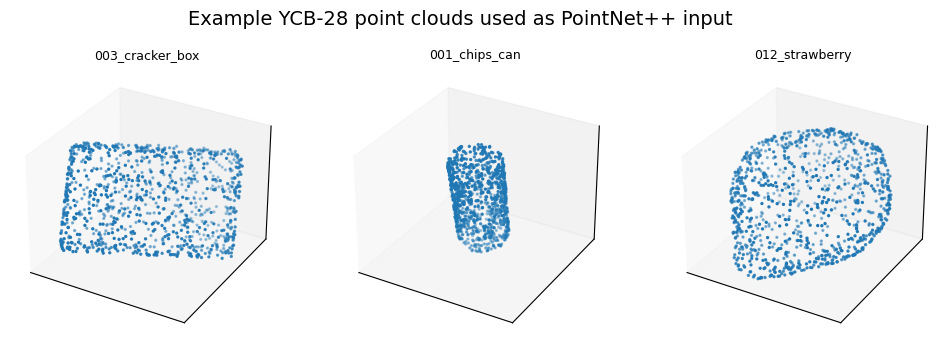

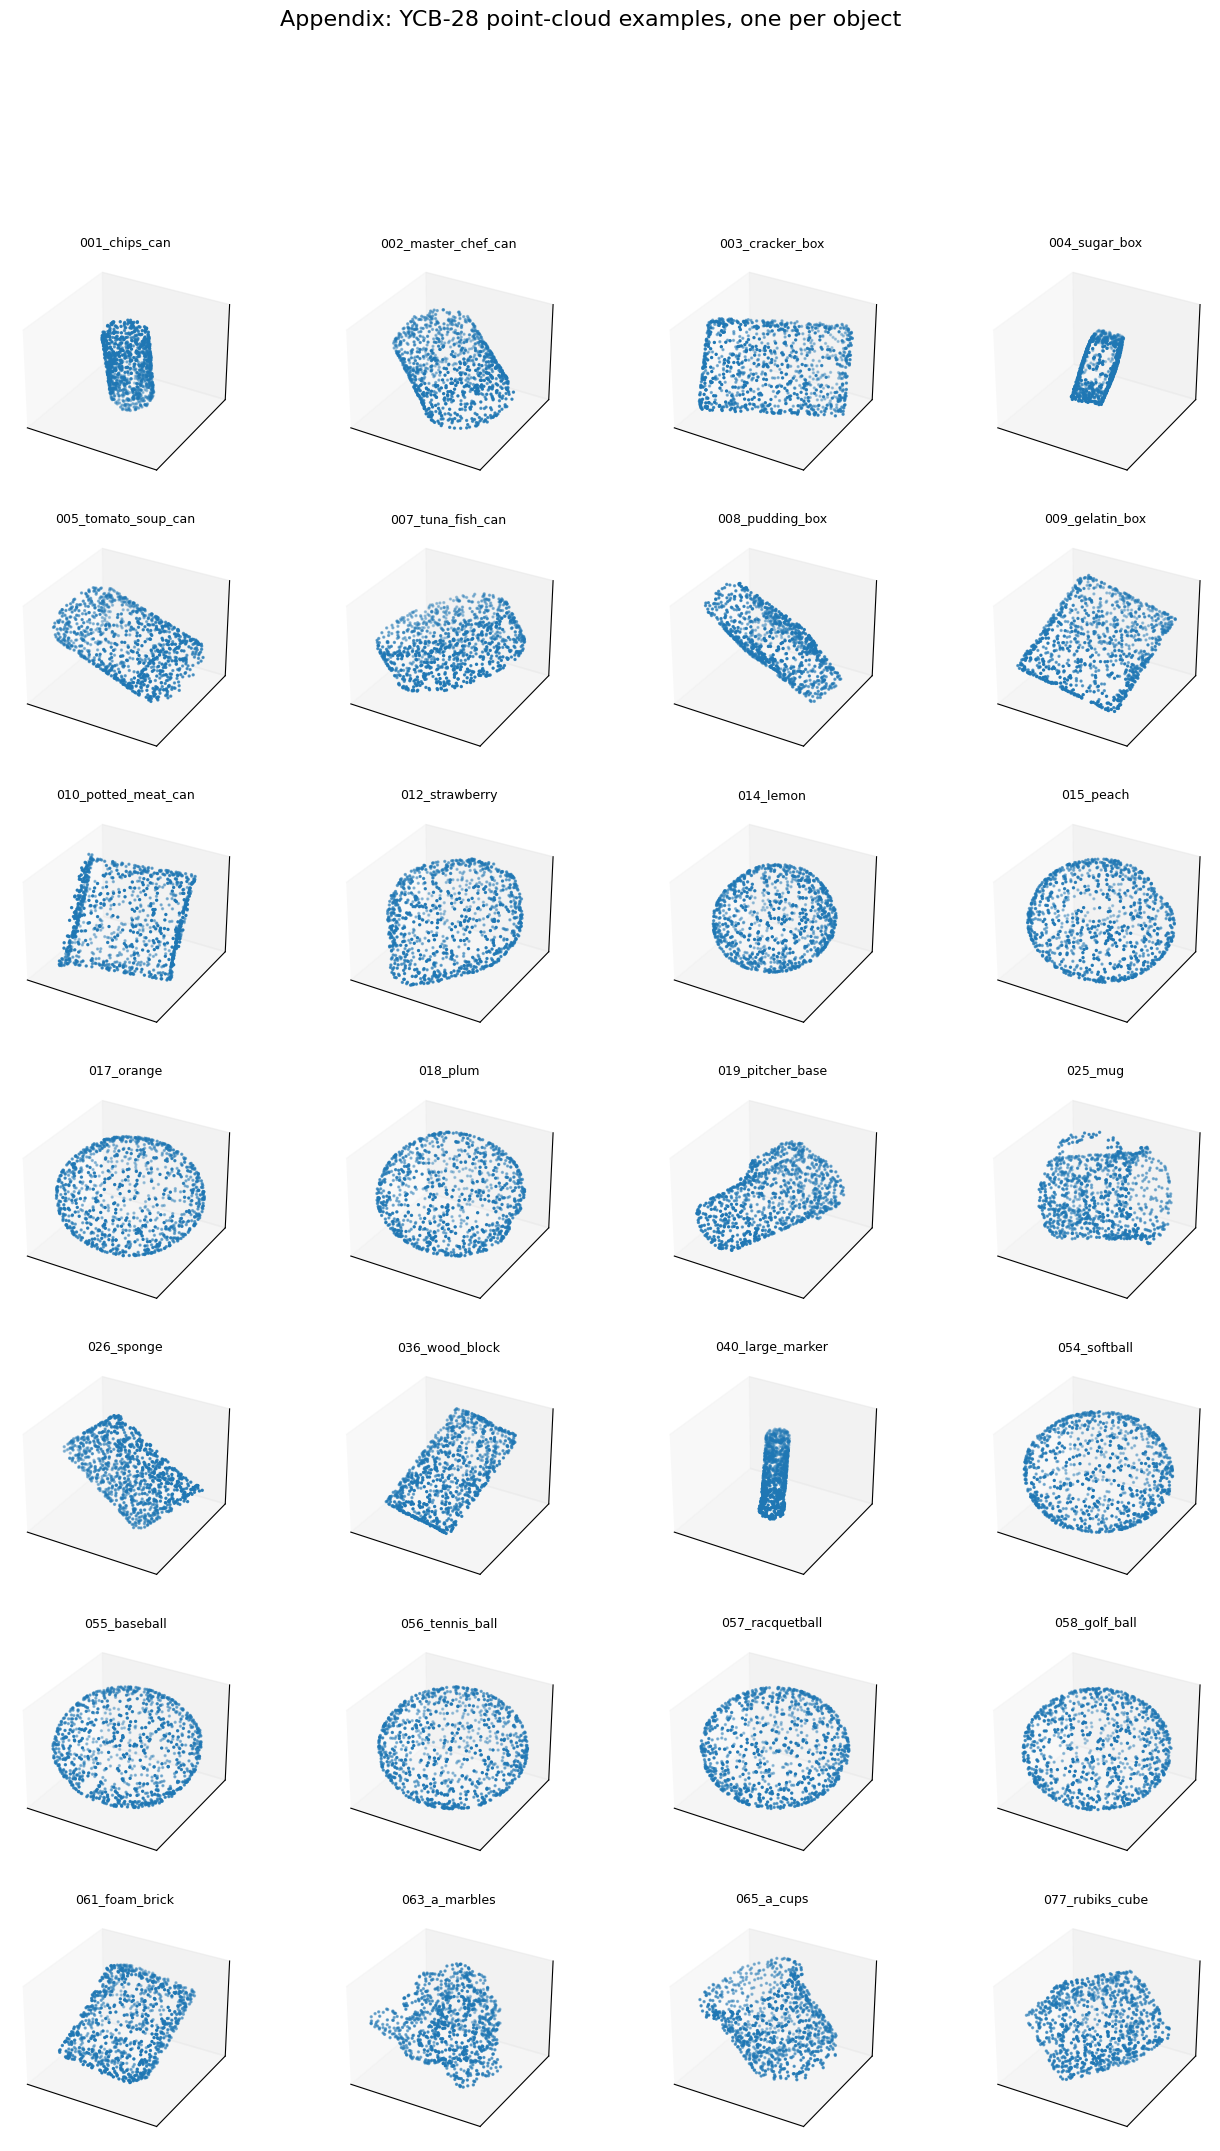

In [15]:
# ============================================================
# CELL 15 — Section 7D: YCB-28 point-cloud examples and appendix grid
# ============================================================

ycb_manifest = safe_read_csv(PATHS["ycb_manifest"])

if ycb_manifest is not None:
    print("YCB manifest columns:")
    print(list(ycb_manifest.columns))
    display(ycb_manifest.head())

ycb_file_col = None
ycb_object_col = None

if ycb_manifest is not None:
    ycb_file_col = find_column(
        ycb_manifest,
        ["file_path", "csv_path", "pointcloud_path", "path", "saved_path"],
        required=False,
        label="YCB point-cloud path"
    )

    ycb_object_col = find_column(
        ycb_manifest,
        ["object_name", "object", "ycb_object", "name"],
        required=False,
        label="YCB object name"
    )

if ycb_manifest is not None and ycb_file_col is not None:

    def make_abs_path(x):
        p = Path(str(x))

        if p.exists():
            return p

        p2 = PROJECT_DIR / str(x)
        if p2.exists():
            return p2

        s = str(x)
        s = s.replace("/content/drive/MyDrive/PointNet_APS_Project_V2", str(PROJECT_DIR))
        s = s.replace("/content/gdrive/MyDrive/PointNet_APS_Project_V2", str(PROJECT_DIR))

        return Path(s)

    ycb_manifest["abs_pointcloud_path"] = ycb_manifest[ycb_file_col].apply(make_abs_path)

    if ycb_object_col is not None:
        ycb_manifest["object_report"] = ycb_manifest[ycb_object_col].astype(str)
    else:
        ycb_manifest["object_report"] = ycb_manifest["abs_pointcloud_path"].apply(lambda p: Path(p).parent.name)

    # Select examples: one box, one cylinder, one sphere if available
    preferred = [
        "003_cracker_box",
        "001_chips_can",
        "012_strawberry"
    ]

    chosen_rows = []

    for obj in preferred:
        sub = ycb_manifest[
            ycb_manifest["object_report"].astype(str).str.contains(obj, case=False, na=False)
        ]

        if len(sub):
            chosen_rows.append(sub.iloc[0])

    if not chosen_rows:
        chosen_rows = [g.iloc[0] for _, g in ycb_manifest.groupby("object_report")][:3]

    # Three YCB point-cloud examples
    fig = plt.figure(figsize=(12, 4))

    for i, row in enumerate(chosen_rows[:3], 1):
        ax = fig.add_subplot(1, 3, i, projection="3d")
        p = row["abs_pointcloud_path"]

        if Path(p).exists():
            xyz = load_pointcloud_csv(p)
            plot_single_pointcloud(ax, xyz, row["object_report"])
        else:
            ax.set_title("Missing file")

    fig.suptitle("Example YCB-28 point clouds used as PointNet++ input", fontsize=14)

    path = POINTCLOUD_DIR / "figure_ycb28_pointcloud_examples.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

    # Appendix: one point cloud per YCB object
    unique_rows = [g.iloc[0] for _, g in ycb_manifest.groupby("object_report")]

    n = len(unique_rows)
    cols = 4
    rows = math.ceil(n / cols)

    fig = plt.figure(figsize=(cols * 4, rows * 3.5))

    for i, row in enumerate(unique_rows, 1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")
        p = row["abs_pointcloud_path"]

        if Path(p).exists():
            xyz = load_pointcloud_csv(p, nmax=1200)
            plot_single_pointcloud(ax, xyz, row["object_report"])
        else:
            ax.set_title("Missing: " + str(row["object_report"])[:20])

    fig.suptitle("Appendix: YCB-28 point-cloud examples, one per object", fontsize=16)

    path = APPENDIX_DIR / "appendix_ycb28_all_object_pointcloud_grid.png"
    fig.savefig(path, dpi=250, bbox_inches="tight")
    print("Saved appendix point-cloud grid:", path)

else:
    print("YCB manifest or point-cloud path column not found. Skipping YCB point-cloud figures.")

YCB image files found: 28
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/pointcloud_visualisations/figure_ycb28_real_image_and_pointcloud_examples.png


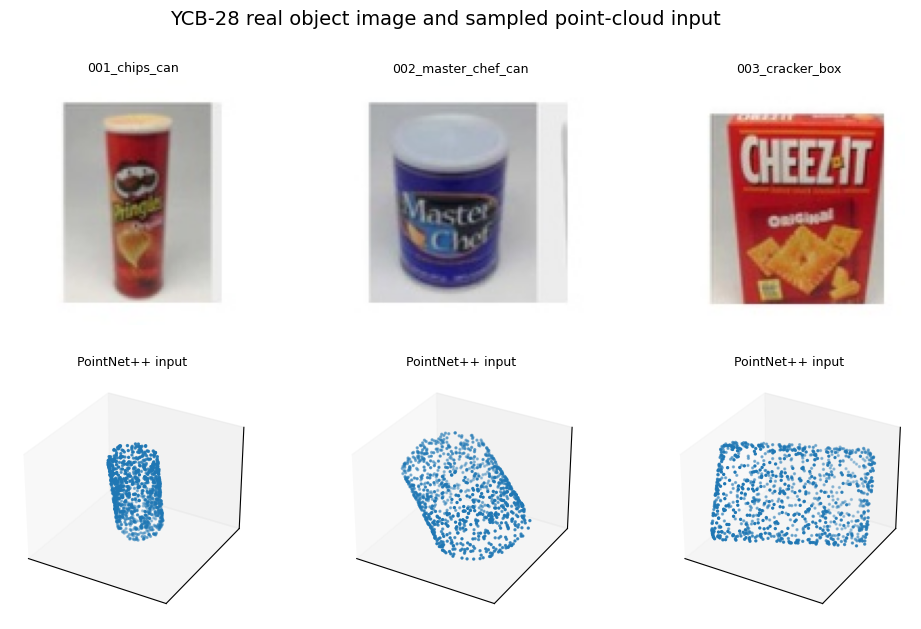

In [16]:
# ============================================================
# CELL 16 — Optional: YCB real image + point-cloud comparison
# ============================================================

image_root = PROJECT_DIR / "data/ycb28/object_images"

if PIL_AVAILABLE and image_root.exists() and ycb_manifest is not None and "abs_pointcloud_path" in ycb_manifest.columns:
    image_files = (
        list(image_root.rglob("*.png")) +
        list(image_root.rglob("*.jpg")) +
        list(image_root.rglob("*.jpeg"))
    )

    print("YCB image files found:", len(image_files))

    pairs = []

    for _, row in ycb_manifest.groupby("object_report").first().reset_index().iterrows():
        obj = str(row["object_report"])

        img_match = None

        for img in image_files:
            if obj.lower() in img.name.lower() or obj.lower() in str(img).lower():
                img_match = img
                break

        if img_match is not None and Path(row["abs_pointcloud_path"]).exists():
            pairs.append((obj, img_match, Path(row["abs_pointcloud_path"])))

        if len(pairs) >= 3:
            break

    if pairs:
        fig = plt.figure(figsize=(12, 7))

        for i, (obj, img_path, pc_path) in enumerate(pairs):
            ax_img = fig.add_subplot(2, len(pairs), i + 1)
            img = Image.open(img_path)
            ax_img.imshow(img)
            ax_img.set_title(obj, fontsize=9)
            ax_img.axis("off")

            ax_pc = fig.add_subplot(2, len(pairs), i + 1 + len(pairs), projection="3d")
            xyz = load_pointcloud_csv(pc_path, nmax=1500)
            plot_single_pointcloud(ax_pc, xyz, "PointNet++ input")

        fig.suptitle("YCB-28 real object image and sampled point-cloud input", fontsize=14)

        path = POINTCLOUD_DIR / "figure_ycb28_real_image_and_pointcloud_examples.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

    else:
        print("No matching image/point-cloud pairs found. Point-cloud-only figure was already created.")

else:
    print("YCB image folder not found or PIL unavailable. Skipping real-image + point-cloud comparison.")

In [17]:
# ============================================================
# CELL 17 — Create final export manifest and ZIP package
# ============================================================

# Save a short README for the export package
readme_text = """
REPORT_EXPORT_PACKAGE

This folder contains report-ready CSV tables, figures and appendix material for:

1. Final AdamW XYZ-only YCB-28 results
2. APS test results
3. Original XYZ+normals vs XYZ-only comparison
4. ModelNet40 primitive-like subset results
5. RProp optimiser comparison
6. Mann–Whitney / Kruskal–Wallis statistical tests
7. PointNet++ and point-cloud visualisations

No additional dataset work is included.
"""

with open(EXPORT_DIR / "README.txt", "w") as f:
    f.write(readme_text)

# Create manifest
rows = []

for folder, label in [
    (TABLE_DIR, "table"),
    (FIG_DIR, "figure"),
    (APPENDIX_DIR, "appendix")
]:
    for p in sorted(folder.rglob("*")):
        if p.is_file():
            rows.append({
                "type": label,
                "file_name": p.name,
                "relative_path": str(p.relative_to(EXPORT_DIR)),
                "absolute_path": str(p)
            })

manifest_df = pd.DataFrame(rows)
manifest_path = EXPORT_DIR / "report_export_manifest.csv"
manifest_df.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
display(manifest_df)

# Create ZIP
zip_path = PROJECT_DIR / "REPORT_EXPORT_PACKAGE.zip"

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(EXPORT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(EXPORT_DIR)))

print("\nDONE.")
print("Export folder:", EXPORT_DIR)
print("ZIP package  :", zip_path)
print("\nUpload this ZIP or the individual CSV/PNG files for final report writing.")

Saved manifest: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/report_export_manifest.csv


,type,file_name,relative_path,absolute_path
0,table,section1_ycb28_adamw_five_number_summary.csv,tables/section1_ycb28_adamw_five_number_summar...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
1,table,section1_ycb28_adamw_run_level_accuracy.csv,tables/section1_ycb28_adamw_run_level_accuracy...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
2,table,section1_ycb28_class_accuracy_per_run.csv,tables/section1_ycb28_class_accuracy_per_run.csv,/content/gdrive/MyDrive/PointNet_APS_Project_V...
3,table,section1_ycb28_class_accuracy_summary.csv,tables/section1_ycb28_class_accuracy_summary.csv,/content/gdrive/MyDrive/PointNet_APS_Project_V...
4,table,section1_ycb28_final_adamw_mixed_aggregated_co...,tables/section1_ycb28_final_adamw_mixed_aggreg...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
...,...,...,...,...
79,appendix,appendix_ycb28_mixed_adamw_confusion_matrix_ru...,appendix/appendix_ycb28_mixed_adamw_confusion_...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
80,appendix,appendix_ycb28_mixed_adamw_confusion_matrix_ru...,appendix/appendix_ycb28_mixed_adamw_confusion_...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
81,appendix,appendix_ycb28_mixed_adamw_confusion_matrix_ru...,appendix/appendix_ycb28_mixed_adamw_confusion_...,/content/gdrive/MyDrive/PointNet_APS_Project_V...
82,appendix,appendix_ycb28_object_accuracy_per_run.csv,appendix/appendix_ycb28_object_accuracy_per_ru...,/content/gdrive/MyDrive/PointNet_APS_Project_V...



DONE.
Export folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE
ZIP package  : /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE.zip

Upload this ZIP or the individual CSV/PNG files for final report writing.


In [18]:
# ============================================================
# CELL 18 — Final checklist
# ============================================================

checklist = pd.DataFrame([
    {
        "section": "1. Final AdamW YCB-28",
        "needed": "Overall accuracy, box plot, class-wise accuracy, confusion matrix, object-wise accuracy",
        "output_location": "tables/section1_*.csv and figures/figure_ycb28_*.png",
        "status": "Check generated files"
    },
    {
        "section": "2. APS results",
        "needed": "APS clean/error/error-double testing and overfitting/status summary",
        "output_location": "tables/section2_*.csv and appendix_notebook6_*.json",
        "status": "Check generated files"
    },
    {
        "section": "3. XYZ+normals vs XYZ-only",
        "needed": "Comparison showing improvement after using XYZ-only input",
        "output_location": "tables/section3_*.csv and figures/figure_ycb28_xyz_normals_*.png",
        "status": "Check generated files"
    },
    {
        "section": "4. ModelNet40",
        "needed": "Subset mapping, single-pass results, 10-vote results, class-wise/category-wise result",
        "output_location": "tables/section4_*.csv and figures/figure_modelnet40_*.png",
        "status": "Check generated files"
    },
    {
        "section": "5. RProp",
        "needed": "RProp runs, class-wise comparison, AdamW vs RProp comparison",
        "output_location": "tables/section5_*.csv and figures/figure_ycb28_adamw_vs_rprop_*.png",
        "status": "Check generated files"
    },
    {
        "section": "6. Statistics",
        "needed": "Pairwise Mann–Whitney tests and Kruskal–Wallis where applicable",
        "output_location": "tables/section6_*.csv",
        "status": "Included in final analysis"
    },
    {
        "section": "7. Figures",
        "needed": "Workflow, PointNet++ diagram, APS/YCB examples, confusion matrices, box plots",
        "output_location": "figures/*.png and figures/pointcloud_visualisations/*.png",
        "status": "Check generated files"
    }
])

display(checklist)
checklist.to_csv(EXPORT_DIR / "final_report_evidence_checklist.csv", index=False)

print("Checklist saved:", EXPORT_DIR / "final_report_evidence_checklist.csv")

,section,needed,output_location,status
0,1. Final AdamW YCB-28,"Overall accuracy, box plot, class-wise accurac...",tables/section1_*.csv and figures/figure_ycb28...,Check generated files
1,2. APS results,APS clean/error/error-double testing and overf...,tables/section2_*.csv and appendix_notebook6_*...,Check generated files
2,3. XYZ+normals vs XYZ-only,Comparison showing improvement after using XYZ...,tables/section3_*.csv and figures/figure_ycb28...,Check generated files
3,4. ModelNet40,"Subset mapping, single-pass results, 10-vote r...",tables/section4_*.csv and figures/figure_model...,Check generated files
4,5. RProp,"RProp runs, class-wise comparison, AdamW vs RP...",tables/section5_*.csv and figures/figure_ycb28...,Check generated files
5,6. Statistics,Pairwise Mann–Whitney tests and Kruskal–Wallis...,tables/section6_*.csv,Included in final analysis
6,7. Figures,"Workflow, PointNet++ diagram, APS/YCB examples...",figures/*.png and figures/pointcloud_visualisa...,Check generated files


Checklist saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/final_report_evidence_checklist.csv


In [20]:
# ============================================================
# FINAL CELL — Save Notebook 09 completion status
# ============================================================

# Ensure point-cloud figure directory is defined
pointcloud_fig_dir = FIG_DIR / "pointcloud_visualisations"
pointcloud_fig_dir.mkdir(parents=True, exist_ok=True)

notebook9_status = {
    "notebook": "09_final_report_results_export",
    "purpose": (
        "Collect final APS, YCB-28, ModelNet40 and RProp results "
        "and export report-ready tables, figures and appendix material."
    ),
    "status": "completed",
    "project_dir": str(PROJECT_DIR),
    "export_dir": str(EXPORT_DIR),

    "output_directories": {
        "tables": str(TABLE_DIR),
        "figures": str(FIG_DIR),
        "appendix": str(APPENDIX_DIR),
        "pointcloud_figures": str(pointcloud_fig_dir)
    },

    "outputs_created": {
        "table_files": len(list(TABLE_DIR.glob("*"))),
        "figure_files": len(list(FIG_DIR.glob("*.png"))),
        "appendix_files": len(list(APPENDIX_DIR.glob("*"))),
        "pointcloud_figure_files": len(
            list(pointcloud_fig_dir.glob("*.png"))
        )
    },

    "experiments_included": [
        "APS robustness evaluation",
        "YCB-28 AdamW evaluation",
        "XYZ + normals versus XYZ-only comparison",
        "ModelNet40 primitive-like subset evaluation",
        "RProp optimizer comparison",
        "statistical comparison"
    ],

    "note": (
        "This notebook performs report-data collection, visualisation "
        "and export only. It does not train new models."
    )
}

status_path = EXPORT_DIR / "09_final_report_results_export_status.json"

with open(status_path, "w") as f:
    json.dump(notebook9_status, f, indent=4)

print("Notebook 09 completed.")
print("Saved status file:")
print(status_path)

print("\nOutput counts:")
for key, value in notebook9_status["outputs_created"].items():
    print(f"{key}: {value}")

notebook9_status

Notebook 09 completed.
Saved status file:
/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/09_final_report_results_export_status.json

Output counts:
table_files: 38
figure_files: 16
appendix_files: 27
pointcloud_figure_files: 3


{'notebook': '09_final_report_results_export',
 'purpose': 'Collect final APS, YCB-28, ModelNet40 and RProp results and export report-ready tables, figures and appendix material.',
 'status': 'completed',
 'project_dir': '/content/gdrive/MyDrive/PointNet_APS_Project_V2',
 'export_dir': '/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE',
 'output_directories': {'tables': '/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/tables',
  'figures': '/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures',
  'appendix': '/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/appendix',
  'pointcloud_figures': '/content/gdrive/MyDrive/PointNet_APS_Project_V2/REPORT_EXPORT_PACKAGE/figures/pointcloud_visualisations'},
 'outputs_created': {'table_files': 38,
  'figure_files': 16,
  'appendix_files': 27,
  'pointcloud_figure_files': 3},
 'experiments_included': ['APS robustness evaluation',
  'YCB-28 AdamW evaluation',
 